---
## 검증셋 BLEU

loss는 토큰 단위 확률만 보므로 "번역이 실제로 좋아졌는가"를 직접 말해주지 않습니다.
validation 표본을 실제로 번역해 corpus BLEU를 재면 비교 가능한 숫자가 나옵니다.

**표본 수에 주의하세요.** 아래 기본값 200문장에서는 BLEU가 7.02로 나오지만,
같은 모델·같은 디코딩으로 1,000문장을 재면 5.86입니다. 표본이 작을수록 점수가
크게 흔들리므로, **시스템 간 비교는 반드시 같은 표본 크기에서** 해야 합니다.
아래 추가 실험에서는 1,000문장 + bootstrap 신뢰구간으로 비교합니다.


---

## 프로젝트 루브릭 대응표

| 평가 기준 | 충족 근거 (셀 위치) | 결과 |
| --- | --- | --- |
| **1. 텍스트 데이터 전처리가 한국어 포함하여 잘 이루어졌다** | Step 2의 `preprocess_sentence`(소문자화 · 구두점 분리 · 언어별 허용 문자 필터 · 공백 정리), `deduplicate_pairs`, `get_korean_tokenizer` → 형태소 분석, Step 3의 `build_split_tensors` | 94,123쌍 → 중복 제거 77,591 → 길이 필터 55,688 → **train 44,551 / val 11,137**. `<unk>` train 1.61% / val 2.52% |
| **2. Attentional Seq2seq 모델이 정상적으로 구동된다** | Step 4의 `BahdanauAttention` · `Encoder` · `Decoder` · `Seq2SeqAttention`, 학습 전 **스모크 테스트 셀** | 파라미터 39,537,696개, `<pad>` attention 최대값 0.00e+00, attention 행 합 1.0 |
| **3. training loss가 안정적으로 떨어진다** | Step 5 학습 루프 + Train/Validation Loss 그래프 셀 | train 6.0144 → 2.7840, 발산·NaN·정체 없음. validation은 **epoch 11에서 최저(6.5273)** 후 상승 → early stopping |
| **4. 테스트용 디코더가 정상 동작하고 의미가 통하는 번역이 나온다** | `greedy_decode` / `translate` / `plot_attention`, best 체크포인트 기준 최종 번역 셀, epoch별 번역 로그 셀 | 형태소 라벨과 정렬된 Attention Map 출력. val BLEU 5.86(1,000문장 기준). 의미는 부분적으로 전달되나 **반복 현상이 남아 있음** — 아래 회고 1-4에 솔직히 정리 |

> 상세 근거와 PRT 항목별 캡쳐 지점은 노트북 맨 아래 **회고 및 프로젝트 정리**에 있습니다.

---


In [1]:
# GPU가 실제로 잡혔는지 먼저 확인 (런타임 > 런타임 유형 변경에서 설정)
import subprocess
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                      "--format=csv,noheader"],
                     capture_output=True, text=True).stdout or "GPU 없음 (CPU 런타임)")

NVIDIA A100-SXM4-80GB, 81920 MiB



In [2]:
# 구글 드라이브 마운트 — 캐시와 체크포인트를 여기에 저장한다.
import os

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/aiffel/s2s_translation"
except ImportError:
    # Colab이 아닌 환경에서도 그대로 동작하도록 로컬 경로로 대체
    PROJECT_DIR = os.path.expanduser("~/aiffel/s2s_translation")

CACHE_DIR = os.path.join(PROJECT_DIR, "cache")
CKPT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
for path in (PROJECT_DIR, CACHE_DIR, CKPT_DIR):
    os.makedirs(path, exist_ok=True)

print("작업 디렉터리:", PROJECT_DIR)

Mounted at /content/drive
작업 디렉터리: /content/drive/MyDrive/aiffel/s2s_translation


In [3]:
# 패키지 설치
import importlib
import sys


def pip_install(*packages):
    """이미 import 가능한 패키지는 건너뛴다."""
    for pkg, mod in packages:
        if importlib.util.find_spec(mod) is None:
            print(f"[install] {pkg}")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                           check=False)
        else:
            print(f"[skip] {pkg}")


pip_install(("konlpy", "konlpy"), ("python-mecab-ko", "mecab"),
            ("kiwipiepy", "kiwipiepy"), ("tqdm", "tqdm"))
subprocess.run("apt-get install -y fonts-nanum > /dev/null 2>&1",
               shell=True, check=False)
print("완료")

[install] konlpy
[install] python-mecab-ko
[install] kiwipiepy
[skip] tqdm
완료


In [4]:
import json
import logging
import pickle
import random
import re
import tarfile
import unicodedata
import urllib.request
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from tqdm.auto import tqdm

SEED = 42


def set_seed(seed=SEED):
    """재현성을 위해 모든 난수 생성기의 시드를 고정한다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    BATCH_SIZE = 256 if gpu_mem_gb >= 35 else 128  # A100(40/80GB)→256, L4(24GB)→128
else:
    BATCH_SIZE = 64

print(f"torch {torch.__version__} | device {device} | batch_size {BATCH_SIZE}")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True   # 입력 크기가 고정이라 켜두면 유리
else:
    print("경고: CPU 런타임입니다. 런타임 유형을 GPU로 바꾸는 것을 권장합니다.")

torch 2.11.0+cu128 | device cuda | batch_size 256


In [5]:
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)          # 캐시에 폰트를 실제로 등록
    fontprop = fm.FontProperties(fname=FONT_PATH, size=12)
    plt.rcParams["font.family"] = fontprop.get_name()
else:
    fontprop = None
    print("나눔폰트를 찾지 못했습니다. 한글이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False
print("폰트:", plt.rcParams["font.family"])

폰트: ['NanumBarunGothic']


## 캐시 헬퍼

무거운 계산의 결과를 드라이브에 저장해 두고, 다음 실행에서는 파일이 있으면 그대로 불러옵니다.
`force=True`를 주면 캐시를 무시하고 다시 계산합니다 (전처리 코드를 고쳤을 때 사용).

In [6]:
def cached(filename, build_fn, force=False, cache_dir=None):
    """계산 결과를 드라이브에 pickle로 캐싱한다.

    Args:
        filename: 캐시 파일 이름
        build_fn: 캐시가 없을 때 실행할 함수. 반환값이 저장된다.
        force: True면 캐시를 무시하고 다시 계산한 뒤 덮어쓴다.
               전처리 로직을 수정했다면 반드시 True로 한 번 실행할 것.

    Returns:
        build_fn()의 결과 (또는 캐시에서 불러온 값)
    """
    cache_dir = cache_dir or CACHE_DIR
    path = os.path.join(cache_dir, filename)

    if os.path.exists(path) and not force:
        with open(path, "rb") as f:
            value = pickle.load(f)
        size_mb = os.path.getsize(path) / 1024 ** 2
        print(f"[캐시 사용] {filename} ({size_mb:.1f} MB)")
        return value

    print(f"[새로 계산] {filename}")
    value = build_fn()
    with open(path, "wb") as f:
        pickle.dump(value, f)
    print(f"[저장 완료] {filename}")
    return value

---
# Step 1. 데이터 다운로드

In [7]:
DATA_URL = (
    "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/"
    "master/korean-english-news-v1/korean-english-park.train.tar.gz"
)


def download_corpus(url=DATA_URL, data_dir=None):
    """말뭉치를 드라이브에 내려받아 압축을 풀고 (ko, en) 문장 리스트를 반환한다."""
    data_dir = data_dir or os.path.join(PROJECT_DIR, "data")
    os.makedirs(data_dir, exist_ok=True)

    tar_path = os.path.join(data_dir, "korean-english-park.train.tar.gz")
    ko_path = os.path.join(data_dir, "korean-english-park.train.ko")
    en_path = os.path.join(data_dir, "korean-english-park.train.en")

    if not os.path.exists(tar_path):
        print("다운로드 중...")
        urllib.request.urlretrieve(url, tar_path)
    if not (os.path.exists(ko_path) and os.path.exists(en_path)):
        print("압축 해제 중...")
        with tarfile.open(tar_path) as tar:
            tar.extractall(data_dir)

    def read_lines(path):
        with open(path, "r", encoding="utf-8") as f:
            return f.read().splitlines()

    return read_lines(ko_path), read_lines(en_path)


kor_raw, eng_raw = download_corpus()
assert len(kor_raw) == len(eng_raw), "병렬 쌍의 줄 수가 다릅니다!"
print(f"전체 병렬 쌍: {len(kor_raw):,}")

전체 병렬 쌍: 94,123


---
# Step 2. 데이터 정제

형태소 분석이 가장 오래 걸리는 단계입니다. 결과를 드라이브에 캐싱합니다.

In [8]:
def deduplicate_pairs(source_lines, target_lines, key="source"):
    """병렬 쌍의 대응을 유지하면서 중복을 제거한다.

    set은 '이미 등장했는지'를 O(1)로 판정하는 용도로만 쓰고,
    결과는 (source, target) 쌍을 순서대로 담은 리스트로 만든다.
    각 언어를 따로 set으로 만들면 순서가 깨져 병렬 쌍이 어긋난다.
    """
    seen = set()
    kept_source, kept_target = [], []

    for src, trg in zip(source_lines, target_lines):
        if key == "source":
            fingerprint = src
        elif key == "target":
            fingerprint = trg
        else:
            fingerprint = (src, trg)

        if fingerprint in seen:
            continue
        seen.add(fingerprint)
        kept_source.append(src)
        kept_target.append(trg)

    return kept_source, kept_target


def preprocess_sentence(sentence, language="en"):
    """언어별 정규식으로 문장을 정제한다.

    1) 소문자화  2) 구두점 앞뒤 띄우기  3) 허용 문자 외 제거  4) 공백 정리
    한국어에 영어용 정규식을 쓰면 한글이 통째로 사라지므로 분기가 필요하다.
    """
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    if language == "ko":
        sentence = re.sub(r"[^가-힣a-z0-9?.!,]+", " ", sentence)
    else:
        sentence = re.sub(r"[^a-z0-9?.!,]+", " ", sentence)

    return re.sub(r"\s+", " ", sentence).strip()


kor_dedup, eng_dedup = deduplicate_pairs(kor_raw, eng_raw, key="source")
cleaned_corpus = list(zip(kor_dedup, eng_dedup))
print(f"중복 제거: {len(kor_raw):,} -> {len(cleaned_corpus):,}쌍")

중복 제거: 94,123 -> 77,591쌍


In [9]:
def get_korean_tokenizer():
    """사용 가능한 한국어 형태소 분석기를 찾아 (이름, morphs 함수)를 반환한다.

    Mecab은 설치 환경을 타므로 우선순위를 두고 순서대로 시도한다.
    """
    try:
        from konlpy.tag import Mecab
        tagger = Mecab()
        tagger.morphs("설치 확인")
        return "konlpy.Mecab", tagger.morphs
    except Exception as err:
        print(f"[1/4] konlpy.Mecab 실패: {type(err).__name__}")

    try:
        from mecab import MeCab
        tagger = MeCab()
        tagger.morphs("설치 확인")
        return "python-mecab-ko", tagger.morphs
    except Exception as err:
        print(f"[2/4] python-mecab-ko 실패: {type(err).__name__}")

    try:
        from kiwipiepy import Kiwi
        kiwi = Kiwi()

        def morphs(text):
            return [token.form for token in kiwi.tokenize(text)]

        morphs("설치 확인")
        return "kiwipiepy", morphs
    except Exception as err:
        print(f"[3/4] kiwipiepy 실패: {type(err).__name__}")

    from konlpy.tag import Okt
    return "konlpy.Okt", Okt().morphs


TOKENIZER_NAME, korean_morphs = get_korean_tokenizer()
print(f"\n사용 형태소 분석기: {TOKENIZER_NAME}")

[1/4] konlpy.Mecab 실패: Exception
[2/4] python-mecab-ko 실패: ModuleNotFoundError

사용 형태소 분석기: kiwipiepy


In [10]:
MAX_TOKEN_LEN = 40
START_TOKEN, END_TOKEN = "<start>", "<end>"


def build_corpus(pairs, max_len=MAX_TOKEN_LEN):
    """정제 -> 토큰화 -> 길이 필터를 수행한다. 형태소 분석 때문에 가장 느린 단계."""
    kor_corpus, eng_corpus = [], []
    for ko_sent, en_sent in tqdm(pairs, desc="토큰화"):
        ko_clean = preprocess_sentence(ko_sent, "ko")
        en_clean = preprocess_sentence(en_sent, "en")
        if not ko_clean or not en_clean:
            continue

        ko_tokens = korean_morphs(ko_clean)
        en_tokens = [START_TOKEN] + en_clean.split() + [END_TOKEN]
        if len(ko_tokens) > max_len or len(en_tokens) > max_len:
            continue

        kor_corpus.append(ko_tokens)
        eng_corpus.append(en_tokens)

    return kor_corpus, eng_corpus


# 캐시 파일 이름에 분석기 이름을 넣어, 분석기가 바뀌면 자동으로 다시 계산되게 한다.
kor_corpus, eng_corpus = cached(
    f"corpus_{TOKENIZER_NAME.replace('.', '_')}_{MAX_TOKEN_LEN}.pkl",
    lambda: build_corpus(cleaned_corpus),
)

print(f"필터 통과: {len(kor_corpus):,}쌍")
print("[KO]", kor_corpus[0])
print("[EN]", eng_corpus[0])

[캐시 사용] corpus_kiwipiepy_40.pkl (19.4 MB)
필터 통과: 55,688쌍
[KO] ['개인', '용', '컴퓨터', '사용', '의', '상당', '부분', '은', '이것', '보다', '뛰어나', 'ᆯ', '수', '있', '느냐', '?']
[EN] ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', 'can', 'you', 'top', 'this', '?', '<end>']


---
# Step 3. 토큰화 (정수 인코딩)

In [11]:
PAD_ID, UNK_ID = 0, 1
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"


class Tokenizer:
    """토큰 리스트를 정수 시퀀스로 바꾸는 최소 기능 토크나이저.

    Keras Tokenizer와 같은 인터페이스(word_index / index_word /
    texts_to_sequences)를 갖도록 만들어 실습 코드와 사용법을 맞췄다.
    """

    def __init__(self, num_words=None):
        self.num_words = num_words
        self.word_index = {PAD_TOKEN: PAD_ID, UNK_TOKEN: UNK_ID}
        self.index_word = {PAD_ID: PAD_TOKEN, UNK_ID: UNK_TOKEN}
        self.word_counts = Counter()

    def fit_on_texts(self, corpus):
        """빈도 상위 num_words개로 어휘 사전을 만든다."""
        for tokens in corpus:
            self.word_counts.update(tokens)

        limit = None if self.num_words is None else self.num_words - 2
        for word, _ in self.word_counts.most_common(limit):
            if word in self.word_index:
                continue
            index = len(self.word_index)
            self.word_index[word] = index
            self.index_word[index] = word

    def texts_to_sequences(self, corpus):
        return [[self.word_index.get(tok, UNK_ID) for tok in tokens]
                for tokens in corpus]

    def sequences_to_text(self, sequence):
        return " ".join(self.index_word.get(i, UNK_TOKEN)
                        for i in sequence if i != PAD_ID)

    def __len__(self):
        return len(self.word_index)


def pad_sequences(sequences, maxlen=None, value=PAD_ID):
    """시퀀스 뒤쪽을 value로 채워 (N, maxlen) 정수 배열을 만든다."""
    if maxlen is None:
        maxlen = max(len(seq) for seq in sequences)
    padded = np.full((len(sequences), maxlen), value, dtype=np.int64)
    for row, seq in enumerate(sequences):
        seq = seq[:maxlen]
        padded[row, :len(seq)] = seq
    return padded


def tokenize(corpus, num_words=None, maxlen=None):
    """코퍼스를 (패딩된 정수 텐서, tokenizer)로 변환한다."""
    tokenizer = Tokenizer(num_words=num_words)
    tokenizer.fit_on_texts(corpus)
    tensor = pad_sequences(tokenizer.texts_to_sequences(corpus), maxlen=maxlen)
    return torch.from_numpy(tensor), tokenizer

In [12]:
NUM_WORDS_KO = 20000
NUM_WORDS_EN = 20000
VAL_RATIO = 0.2
SPLIT_SEED = 42


def split_indices(n, val_ratio=VAL_RATIO, seed=SPLIT_SEED):
    """전체 인덱스를 섞어 (train, val)로 나눈다.

    분할 시드를 별도 상수로 고정하는 이유: 재실행마다 분할이 달라지면 직전 실행의
    val 문장이 이번 실행의 train으로 넘어간다. 그러면 val loss가 '이미 학습에 쓰인
    문장'에 대한 loss가 되어 과적합 신호를 놓친다.

    Args:
        n: 전체 표본 수.
        val_ratio: 검증셋 비율.
        seed: 분할 재현용 시드.

    Returns:
        (train 인덱스 리스트, val 인덱스 리스트)
    """
    generator = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=generator)
    n_val = int(n * val_ratio)
    return perm[n_val:].tolist(), perm[:n_val].tolist()


def build_split_tensors():
    """train으로만 어휘 사전을 만들고, 그 사전으로 train/val을 함께 인코딩한다.

    전체 코퍼스로 fit하면 val에만 등장하는 단어까지 사전에 들어가 <unk>가 되지
    않는다. 모델이 실전에서 만날 미등록어 부담이 val에서 사라져 val loss가
    낙관적으로 나오는, 전형적인 누수 경로다. 사전은 train만 보고 만든다.

    Returns:
        dict — train/val 텐서 4개, tokenizer 2개, 분할 인덱스 2개
    """
    train_idx, val_idx = split_indices(len(kor_corpus))

    kor_train = [kor_corpus[i] for i in train_idx]
    eng_train = [eng_corpus[i] for i in train_idx]
    kor_val = [kor_corpus[i] for i in val_idx]
    eng_val = [eng_corpus[i] for i in val_idx]

    kor_tk = Tokenizer(num_words=NUM_WORDS_KO)
    kor_tk.fit_on_texts(kor_train)
    eng_tk = Tokenizer(num_words=NUM_WORDS_EN)
    eng_tk.fit_on_texts(eng_train)

    def encode(corpus, tokenizer):
        # maxlen을 상수로 고정한다. 기본값(코퍼스 내 최대 길이)을 쓰면 train과 val의
        # 패딩 길이가 달라져, 같은 모델에 넣을 때 shape이 어긋난다.
        sequences = tokenizer.texts_to_sequences(corpus)
        return torch.from_numpy(pad_sequences(sequences, maxlen=MAX_TOKEN_LEN))

    return {"kor_train": encode(kor_train, kor_tk),
            "eng_train": encode(eng_train, eng_tk),
            "kor_val": encode(kor_val, kor_tk),
            "eng_val": encode(eng_val, eng_tk),
            "kor_tokenizer": kor_tk, "eng_tokenizer": eng_tk,
            "train_idx": train_idx, "val_idx": val_idx}


# 캐시 이름에 분할 비율과 시드를 넣어, 분할을 바꾸면 자동으로 다시 계산되게 한다.
CACHE_NAME = (f"tensors_split_{TOKENIZER_NAME.replace('.', '_')}"
              f"_{NUM_WORDS_KO}_{NUM_WORDS_EN}"
              f"_v{int(VAL_RATIO * 100)}s{SPLIT_SEED}.pkl")
split_data = cached(CACHE_NAME, build_split_tensors)

# 이후 셀들이 쓰던 이름을 그대로 유지한다 (translate 등이 kor_tokenizer를 참조).
kor_tensor, eng_tensor = split_data["kor_train"], split_data["eng_train"]
kor_val_tensor, eng_val_tensor = split_data["kor_val"], split_data["eng_val"]
kor_tokenizer = split_data["kor_tokenizer"]
eng_tokenizer = split_data["eng_tokenizer"]

INPUT_DIM = len(kor_tokenizer)
OUTPUT_DIM = len(eng_tokenizer)
SOS_ID = eng_tokenizer.word_index[START_TOKEN]
EOS_ID = eng_tokenizer.word_index[END_TOKEN]


def unk_ratio(tensor):
    """<pad>를 제외한 토큰 중 <unk>의 비율."""
    return (tensor == UNK_ID).sum().item() / (tensor != PAD_ID).sum().item()


print(f"train {len(kor_tensor):,}쌍 | val {len(kor_val_tensor):,}쌍")
print(f"KO 어휘 {INPUT_DIM:,} | <unk> train {unk_ratio(kor_tensor):.2%} "
      f"/ val {unk_ratio(kor_val_tensor):.2%}")
print(f"EN 어휘 {OUTPUT_DIM:,} | <unk> train {unk_ratio(eng_tensor):.2%} "
      f"/ val {unk_ratio(eng_val_tensor):.2%}")
print(f"<start>={SOS_ID}, <end>={EOS_ID}, <pad>={PAD_ID}")
print("\nval의 <unk> 비율이 train보다 높은 것이 정상입니다 "
      "(사전을 train만 보고 만들었기 때문).")


[캐시 사용] tensors_split_kiwipiepy_20000_20000_v20s42.pkl (35.6 MB)
train 44,551쌍 | val 11,137쌍
KO 어휘 20,000 | <unk> train 1.61% / val 2.52%
EN 어휘 20,000 | <unk> train 1.57% / val 2.51%
<start>=4, <end>=5, <pad>=0

val의 <unk> 비율이 train보다 높은 것이 정상입니다 (사전을 train만 보고 만들었기 때문).


In [13]:
train_dataset = TensorDataset(kor_tensor, eng_tensor)
val_dataset = TensorDataset(kor_val_tensor, eng_val_tensor)
pin = (device.type == "cuda")

data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                         drop_last=True, pin_memory=pin)
# val은 섞을 이유가 없고, 마지막 배치도 버리지 않는다 (전체를 다 평가해야 한다).
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        drop_last=False, pin_memory=pin)

print(f"train 배치 {len(data_loader):,}개 | val 배치 {len(val_loader):,}개 "
      f"(batch_size={BATCH_SIZE})")


train 배치 174개 | val 배치 44개 (batch_size=256)


---
# Step 4. 모델

In [14]:
class BahdanauAttention(nn.Module):
    """Bahdanau(additive) attention.

    score(s_{t-1}, h_j) = v^T · tanh(W1·h_j + W2·s_{t-1})

    src_mask가 주어지면 <pad> 위치의 점수를 -inf로 만들어 softmax에서 배제한다.
    이 마스킹이 없으면 모델이 의미 없는 <pad> 자리에 주의를 분산한다.
    """

    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, src_mask=None):
        """hidden (B,H), encoder_outputs (src_len,B,H) -> attention (B,src_len)"""
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        score = self.v(energy).squeeze(2)

        if src_mask is not None:
            score = score.masked_fill(~src_mask, -1e9)

        return F.softmax(score, dim=1)


class Encoder(nn.Module):
    """소스 문장을 읽어 모든 time-step의 hidden state를 내놓는 GRU 인코더."""

    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_ID)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        """src (src_len,B) -> outputs (src_len,B,H), hidden (1,B,H)"""
        embedded = self.dropout(self.embedding(src))
        return self.rnn(embedded)


class Decoder(nn.Module):
    """한 스텝씩 단어를 생성하는 attention 디코더.

    Bahdanau 원논문의 계산 경로를 따른다: s_{t-1} -> a_t -> c_t -> s_t -> 예측.
    즉 context가 GRU의 '입력'으로 들어가 다음 hidden state를 만드는 데 관여한다.
    """

    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.1):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_ID)
        self.rnn = nn.GRU(emb_dim + hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim * 2 + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs, src_mask=None):
        """input_token (B,) -> prediction (B,vocab), hidden, attn (B,src_len)"""
        input_token = input_token.unsqueeze(0)
        embedded = self.dropout(self.embedding(input_token))

        attn = self.attention(hidden[-1], encoder_outputs, src_mask)
        context = torch.bmm(attn.unsqueeze(1),
                            encoder_outputs.permute(1, 0, 2)).permute(1, 0, 2)

        output, hidden = self.rnn(torch.cat((embedded, context), dim=2), hidden)
        prediction = self.fc_out(torch.cat(
            (output.squeeze(0), context.squeeze(0), embedded.squeeze(0)), dim=1))

        return prediction, hidden, attn

In [15]:
class Seq2SeqAttention(nn.Module):
    """Encoder-Decoder를 묶어 한 문장을 끝까지 생성하는 래퍼."""

    def __init__(self, encoder, decoder, device, pad_id=PAD_ID):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.pad_id = pad_id

    def make_src_mask(self, src):
        """(src_len,B) -> (B,src_len) bool. True가 유효 토큰."""
        return (src != self.pad_id).permute(1, 0)

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5,
                max_len=50, sos_id=None, eos_id=None):
        """학습 시 trg를 주고, 추론 시 None을 준다.

        outputs의 index 0은 비어 있고 t>=1이 trg[t]에 대한 예측이다 (한 칸 shift).
        """
        sos_id = SOS_ID if sos_id is None else sos_id
        eos_id = EOS_ID if eos_id is None else eos_id

        src_mask = self.make_src_mask(src)
        encoder_outputs, hidden = self.encoder(src)

        batch_size, src_len = src.shape[1], src.shape[0]
        steps = trg.shape[0] if trg is not None else max_len

        outputs = torch.zeros(steps, batch_size, self.decoder.output_dim,
                              device=self.device)
        attentions = torch.zeros(steps, batch_size, src_len, device=self.device)

        if trg is not None:
            input_token = trg[0]
        else:
            input_token = torch.full((batch_size,), sos_id, dtype=torch.long,
                                     device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

        for t in range(1, steps):
            prediction, hidden, attn = self.decoder(
                input_token, hidden, encoder_outputs, src_mask)
            outputs[t] = prediction
            attentions[t] = attn
            top1 = prediction.argmax(1)

            if trg is not None:
                use_teacher = random.random() < teacher_forcing_ratio
                input_token = trg[t] if use_teacher else top1
            else:
                input_token = top1
                finished |= (top1 == eos_id)
                if finished.all():
                    outputs, attentions = outputs[:t + 1], attentions[:t + 1]
                    break

        return outputs, attentions


EMB_DIM = 256
HIDDEN_DIM = 512
DROPOUT = 0.1


def build_model(input_dim=None, output_dim=None, emb_dim=EMB_DIM,
                hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
    """모델 3종을 조립해 device로 옮겨 반환한다."""
    input_dim = INPUT_DIM if input_dim is None else input_dim
    output_dim = OUTPUT_DIM if output_dim is None else output_dim

    encoder = Encoder(input_dim, emb_dim, hidden_dim, dropout)
    attention = BahdanauAttention(hidden_dim)
    decoder = Decoder(output_dim, emb_dim, hidden_dim, attention, dropout)
    return Seq2SeqAttention(encoder, decoder, device).to(device)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [16]:
# 스모크 테스트: 학습을 시작하기 전에 shape과 마스킹이 정상인지 확인한다.
set_seed()
model = build_model()
print(f"학습 가능 파라미터: {count_parameters(model):,}")

sample_src, sample_trg = next(iter(data_loader))
model.eval()
with torch.no_grad():
    dummy_src = sample_src.transpose(0, 1).to(device)
    dummy_trg = sample_trg.transpose(0, 1).to(device)
    out_train, attn_train = model(dummy_src, dummy_trg, teacher_forcing_ratio=1.0)
    out_infer, _ = model(dummy_src, None, max_len=20)

mask = model.make_src_mask(dummy_src)
pad_attn = attn_train[1:][:, ~mask].abs().max().item() if (~mask).any() else 0.0

print("학습 outputs:", tuple(out_train.shape), "| 추론 outputs:", tuple(out_infer.shape))
print(f"<pad> attention 최대값: {pad_attn:.2e} (0이어야 정상)")
print("attention 합:", attn_train[1].sum(dim=1)[:3].tolist(), "(1이어야 정상)")

학습 가능 파라미터: 39,537,696
학습 outputs: (40, 256, 20000) | 추론 outputs: (20, 256, 20000)
<pad> attention 최대값: 0.00e+00 (0이어야 정상)
attention 합: [1.0, 1.0, 1.0] (1이어야 정상)


---
# Step 5. 학습 (validation · early stopping · 체크포인트)

매 epoch마다 **train loss와 validation loss를 함께** 재고, 상태를 드라이브에 저장합니다.
런타임이 끊겨도 중단된 epoch부터 이어집니다.

| 장치 | 설정 | 이유 |
| --- | --- | --- |
| teacher forcing 스케줄 | 1.0 → 0.5 (epoch당 -0.05) | 초반엔 정답을 넣어 문법을 익히고, 뒤로 갈수록 추론 조건에 가깝게 (exposure bias 완화) |
| validation | 매 epoch, `tf=0` | 추론과 같은 조건에서 재야 실제 성능 신호가 됨 |
| early stopping | patience 5, min delta 1e-3 | val이 더 내려가지 않으면 그 뒤 학습은 과적합 |
| best 분리 저장 | `*_best.pt` | 마지막 epoch ≠ 가장 좋은 epoch |

> ⚠️ **옵티마이저 상태를 함께 저장하는 이유**: Adam은 각 파라미터의 1·2차 모멘트를
> 누적하고 있습니다. 가중치만 복원하고 옵티마이저를 새로 만들면 그 누적값이 0으로
> 초기화되어, 재개 직후 몇 스텝 동안 학습이 불안정해집니다.
>
> ⚠️ **early stopping 카운터도 저장합니다**: 이것을 빼먹으면 재개할 때마다 카운터가
> 0으로 돌아가, 이미 과적합이 시작된 모델을 patience만큼 더 학습하게 됩니다.


In [17]:
# 앞선 설정(baseline · small 모델) 실험 결과를 덮어쓰지 않도록 파일 이름을 분리한다.
CKPT_PATH = os.path.join(CKPT_DIR, "seq2seq_attn_tf_schedule.pt")       # 마지막 상태
BEST_PATH = os.path.join(CKPT_DIR, "seq2seq_attn_tf_schedule_best.pt")  # val 최저
LOG_PATH = os.path.join(CKPT_DIR, "translation_log_tf_schedule.json")


def current_config():
    """체크포인트 호환성을 판정하는 기준값. 하나라도 다르면 이어서 학습할 수 없다."""
    return {"emb_dim": EMB_DIM, "hidden_dim": HIDDEN_DIM, "input_dim": INPUT_DIM,
            "output_dim": OUTPUT_DIM, "val_ratio": VAL_RATIO,
            "split_seed": SPLIT_SEED}


def save_checkpoint(model, optimizer, epoch, history, best_val, bad_epochs,
                    path=CKPT_PATH):
    """재개에 필요한 상태를 통째로 저장한다.

    best_val과 bad_epochs까지 저장하는 이유: 이것을 빼먹으면 런타임이 끊겼다가
    재개할 때 early stopping 카운터가 0으로 초기화되어, 이미 과적합이 시작된
    모델을 patience만큼 더 학습하게 된다.
    """
    torch.save({"epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "history": history,
                "best_val": best_val,
                "bad_epochs": bad_epochs,
                "config": current_config()}, path)


def load_checkpoint(model, optimizer, path=CKPT_PATH):
    """체크포인트가 있으면 복원한다. 없으면 처음부터 학습할 초기값을 준다.

    Returns:
        (완료된 epoch 수, history dict, best_val, bad_epochs)
    """
    if not os.path.exists(path):
        print("[체크포인트 없음] 처음부터 학습합니다.")
        return 0, {"train": [], "val": []}, float("inf"), 0

    # 직접 저장한 파일이므로 weights_only=False로 읽는다.
    ckpt = torch.load(path, map_location=device, weights_only=False)
    if ckpt["config"] != current_config():
        # 어휘 크기나 분할이 바뀌면 가중치 shape과 평가 기준이 맞지 않는다.
        raise ValueError(f"설정 불일치\n저장됨: {ckpt['config']}\n"
                         f"현재:   {current_config()}\n"
                         "체크포인트를 지우거나 설정을 되돌리세요.")

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    print(f"[체크포인트 복원] epoch {ckpt['epoch']}까지 완료 "
          f"(best val {ckpt['best_val']:.4f}, 개선 없음 {ckpt['bad_epochs']}회)")
    return ckpt["epoch"], ckpt["history"], ckpt["best_val"], ckpt["bad_epochs"]


def load_best(model, path=BEST_PATH):
    """val loss가 가장 낮았던 가중치를 모델에 올린다.

    Returns:
        best 가중치의 epoch 번호. 파일이 없으면 None.
    """
    if not os.path.exists(path):
        print("[best 체크포인트 없음] 현재 가중치를 그대로 씁니다.")
        return None

    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    print(f"[best 복원] epoch {ckpt['epoch']} | val loss {ckpt['best_val']:.4f}")
    return ckpt["epoch"]


def append_log(epoch, translations, path=LOG_PATH):
    """epoch별 번역 결과를 누적 저장한다.

    임시 파일에 쓴 뒤 os.replace로 교체한다. 드라이브에 직접 쓰는 도중 런타임이
    끊기면 파일이 깨지거나 해당 epoch 기록이 통째로 누락된다 (이전 실행에서
    epoch 11, 25가 빠진 것이 이 경우로 추정된다).
    """
    log = []
    if os.path.exists(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                log = json.load(f)
        except json.JSONDecodeError:
            print("[경고] 로그 파일이 손상되어 새로 시작합니다.")

    log = [entry for entry in log if entry["epoch"] != epoch]  # 재실행 시 중복 방지
    log.append({"epoch": epoch, "translations": translations})
    log.sort(key=lambda e: e["epoch"])

    tmp_path = path + ".tmp"
    with open(tmp_path, "w", encoding="utf-8") as f:
        json.dump(log, f, ensure_ascii=False, indent=1)
    os.replace(tmp_path, path)      # 원자적 교체


In [18]:
def train_epoch(model, loader, optimizer, criterion,
                teacher_forcing_ratio=0.5, clip=1.0, desc="Epoch"):
    """한 epoch을 학습하고 평균 loss를 반환한다."""
    model.train()
    epoch_loss = 0.0
    progress = tqdm(loader, desc=desc, leave=False)

    for src, trg in progress:
        # DataLoader는 (B,L)을 주지만 모델은 (L,B)를 기대한다.
        # 이 전치를 빠뜨리면 에러 없이 batch 축과 시간 축이 뒤바뀐 채 학습된다.
        src = src.transpose(0, 1).to(device, non_blocking=True)
        trg = trg.transpose(0, 1).to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs, _ = model(src, trg, teacher_forcing_ratio=teacher_forcing_ratio)

        # index 0(<start> 자리)은 예측이 없으므로 버리고 한 칸 밀어 정렬한다.
        loss = criterion(outputs[1:].reshape(-1, outputs.shape[-1]),
                         trg[1:].reshape(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    return epoch_loss / len(loader)

In [19]:
@torch.no_grad()
def evaluate(model, loader, criterion, teacher_forcing_ratio=0.0, desc="Val"):
    """검증 loss를 계산한다. 기본값은 teacher forcing 없이(추론과 같은 조건).

    주의: 이 값은 train loss와 **절대값을 비교할 수 없다.** train은 teacher
    forcing이 걸린 상태의 loss라 조건이 다르고, 그래서 val이 항상 더 높게 나온다.
    봐야 할 것은 두 곡선의 간격이 아니라 **val 곡선이 방향을 바꾸는 지점**이다.

    Returns:
        배치 평균 loss (float)
    """
    model.eval()
    total_loss = 0.0

    for src, trg in tqdm(loader, desc=desc, leave=False):
        src = src.transpose(0, 1).to(device, non_blocking=True)
        trg = trg.transpose(0, 1).to(device, non_blocking=True)

        outputs, _ = model(src, trg, teacher_forcing_ratio=teacher_forcing_ratio)
        loss = criterion(outputs[1:].reshape(-1, outputs.shape[-1]),
                         trg[1:].reshape(-1))
        total_loss += loss.item()

    return total_loss / len(loader)


In [20]:
def encode_source(sentence, tokenizer=None, max_len=MAX_TOKEN_LEN):
    """번역할 한국어 문장을 (텐서, 실제 토큰 리스트)로 변환한다.

    Attention Map의 x축 라벨을 여기서 함께 반환하는 것이 중요하다.
    인코더가 실제로 본 단위는 형태소인데 공백 어절을 라벨로 쓰면 열과 라벨이 어긋난다.
    """
    tokenizer = tokenizer or kor_tokenizer
    tokens = korean_morphs(preprocess_sentence(sentence, "ko"))[:max_len]
    ids = [tokenizer.word_index.get(tok, UNK_ID) for tok in tokens]
    tensor = torch.tensor(ids, dtype=torch.long).unsqueeze(1).to(device)
    return tensor, tokens


def greedy_decode(model, src_tensor, max_len=50,
                  no_repeat_ngram_sizes=(2, 3), max_consecutive_repeat=2,
                  sos_id=None, eos_id=None):
    """반복 억제를 적용한 탐욕적 디코딩.

    학습 경로(model.forward)는 건드리지 않고 추론 방식만 바꾼다.

    두 규칙을 함께 쓴다.
      1) n-gram 중복 차단: 이미 나온 적 있는 n-gram을 다시 만드는 후보를 건너뛴다.
         (2,3)처럼 여러 크기를 걸면 2단어 반복과 3단어 구 반복을 함께 잡는다.
      2) 연속 반복 상한: n-gram 메모리는 '이미 등장한' 조합만 막으므로,
         그 조합이 처음 만들어지는 순간은 못 막는다. 이 규칙이 그 빈틈을 메운다.

    상위 후보가 전부 막히면 최고 확률 토큰을 그대로 쓴다 (무한 탐색 방지).
    """
    sos_id = SOS_ID if sos_id is None else sos_id
    eos_id = EOS_ID if eos_id is None else eos_id

    model.eval()
    src_mask = model.make_src_mask(src_tensor)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

        generated = [sos_id]
        seen_ngrams = {n: set() for n in no_repeat_ngram_sizes}
        attentions = []
        input_token = torch.tensor([sos_id], device=device)

        for _ in range(max_len - 1):
            logits, hidden, attn = model.decoder(
                input_token, hidden, encoder_outputs, src_mask)
            attentions.append(attn.squeeze(0).cpu())

            ranked = torch.argsort(logits.squeeze(0), descending=True).tolist()
            next_token = ranked[0]

            for candidate in ranked[:50]:      # 상위 50개만 검사 (속도)
                if (max_consecutive_repeat > 0
                        and len(generated) >= max_consecutive_repeat
                        and all(t == candidate
                                for t in generated[-max_consecutive_repeat:])):
                    continue

                blocked = False
                for n in no_repeat_ngram_sizes:
                    if len(generated) >= n - 1:
                        prefix = tuple(generated[-(n - 1):]) if n > 1 else ()
                        if prefix + (candidate,) in seen_ngrams[n]:
                            blocked = True
                            break
                if blocked:
                    continue

                next_token = candidate
                break

            for n in no_repeat_ngram_sizes:
                if len(generated) >= n - 1:
                    prefix = tuple(generated[-(n - 1):]) if n > 1 else ()
                    seen_ngrams[n].add(prefix + (next_token,))

            generated.append(next_token)
            input_token = torch.tensor([next_token], device=device)
            if next_token == eos_id:
                break

    stacked = torch.stack(attentions) if attentions else torch.empty(0)
    return generated[1:], stacked


def translate(sentence, model, no_repeat=True, max_len=50, **decode_kwargs):
    """한국어 문장 하나를 영어로 번역한다.

    Args:
        no_repeat: False면 반복 억제 없는 순수 greedy로 디코딩한다 (비교용).

    Returns:
        (예측 토큰 리스트, 소스 토큰 리스트, attention (trg_len, src_len))
    """
    src_tensor, src_tokens = encode_source(sentence)

    if no_repeat:
        pred_ids, attention = greedy_decode(model, src_tensor, max_len=max_len,
                                            **decode_kwargs)
        attention = attention.numpy()
    else:
        model.eval()
        with torch.no_grad():
            outputs, attn = model(src_tensor, None, max_len=max_len)
        pred_ids = outputs[1:].argmax(2).squeeze(1).tolist()
        attention = attn[1:].squeeze(1).cpu().numpy()

    if EOS_ID in pred_ids:
        cut = pred_ids.index(EOS_ID) + 1
        pred_ids, attention = pred_ids[:cut], attention[:cut]

    result = [eng_tokenizer.index_word.get(i, UNK_TOKEN) for i in pred_ids]
    return result, src_tokens, attention


def plot_attention(attention, src_tokens, pred_tokens, title=""):
    """Attention Map을 그린다. 축 라벨은 모델이 실제로 본 토큰과 일치시킨다."""
    attention = attention[:len(pred_tokens), :len(src_tokens)]

    fig, ax = plt.subplots(figsize=(max(4, len(src_tokens) * 0.55),
                                    max(3, len(pred_tokens) * 0.45)))
    ax.matshow(attention, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=90, fontproperties=fontprop)
    ax.set_yticks(range(len(pred_tokens)))
    ax.set_yticklabels(pred_tokens, fontproperties=fontprop)
    ax.set_title(title, fontproperties=fontprop, pad=20)
    plt.tight_layout()
    plt.show()


TEST_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

# 진단용 probe 문장 — 반복이 특정 고유명사 문제인지 모델 전반의 문제인지 구분한다.
PROBE_SENTENCES = [
    "그는 학교에 간다.",
    "날씨가 좋아서 기분이 좋다.",
    "회사는 새로운 제품을 출시했다.",
    "그녀는 어제 친구를 만났다.",
]


def show_samples(model, sentences=TEST_SENTENCES, no_repeat=True):
    """예문 번역 결과를 출력하고 {문장: 번역} dict로 반환한다."""
    results = {}
    for sentence in sentences:
        tokens, _, _ = translate(sentence, model, no_repeat=no_repeat)
        text = " ".join(tokens)
        results[sentence] = text
        print(f"  {sentence}  ->  {text}")
    return results

In [21]:
EPOCHS = 60                 # 상한. early stopping이 먼저 걸리는 것이 정상이다.
LEARNING_RATE = 1e-3
PATIENCE = 5                # val loss가 이 횟수만큼 연속으로 개선되지 않으면 중단
MIN_DELTA = 1e-3            # 이보다 작은 개선은 개선으로 치지 않는다


def teacher_forcing_schedule(epoch):
    """teacher forcing 비율을 1.0에서 0.5까지 epoch마다 0.05씩 낮춘다.

    초반에는 정답 토큰을 그대로 넣어 빠르게 문법을 익히게 하고, 뒤로 갈수록
    자기 예측을 입력으로 받게 해 추론 조건에 가깝게 만든다 (exposure bias 완화).

    Args:
        epoch: 0부터 시작하는 epoch 번호.

    Returns:
        해당 epoch의 teacher forcing 비율. epoch 10 이후로는 0.5 고정.
    """
    return max(0.5, 1.0 - epoch * 0.05)


set_seed()
model = build_model()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

start_epoch, history, best_val, bad_epochs = load_checkpoint(model, optimizer)

# 이미 조기 종료 조건을 넘긴 상태로 복원됐다면 학습을 재개하지 않는다.
# 이 검사가 없으면 재개할 때마다 과적합된 모델을 한 epoch씩 더 돌리게 된다.
if bad_epochs >= PATIENCE:
    print(f"이미 조기 종료 조건을 충족했습니다 (개선 없음 {bad_epochs}회). "
          "학습을 건너뜁니다.")
    print("더 돌리려면 PATIENCE를 올리거나 체크포인트를 지우세요.")
else:
    print(f"epoch {start_epoch + 1}부터 최대 {EPOCHS}까지 학습합니다.\n")

    for epoch in range(start_epoch, EPOCHS):
        tf_ratio = teacher_forcing_schedule(epoch)

        train_loss = train_epoch(model, data_loader, optimizer, criterion,
                                 teacher_forcing_ratio=tf_ratio,
                                 desc=f"Epoch {epoch + 1}/{EPOCHS}")
        val_loss = evaluate(model, val_loader, criterion,
                            desc=f"Val {epoch + 1}/{EPOCHS}")

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        improved = val_loss < best_val - MIN_DELTA
        if improved:
            best_val, bad_epochs = val_loss, 0
            torch.save({"epoch": epoch + 1, "model_state": model.state_dict(),
                        "best_val": best_val, "config": current_config()},
                       BEST_PATH)
        else:
            bad_epochs += 1

        status = ("  ← best" if improved
                  else f"  (개선 없음 {bad_epochs}/{PATIENCE})")
        print(f"[Epoch {epoch + 1:2d}] tf {tf_ratio:.2f} | "
              f"train {train_loss:.4f} | val {val_loss:.4f}{status}")

        translations = show_samples(model)
        save_checkpoint(model, optimizer, epoch + 1, history, best_val,
                        bad_epochs)
        append_log(epoch + 1, translations)
        print()

        if bad_epochs >= PATIENCE:
            print(f"조기 종료: val loss가 {PATIENCE} epoch 연속 "
                  "개선되지 않았습니다.")
            break

print(f"학습 종료. best val loss {best_val:.4f}")
print("마지막 상태:", CKPT_PATH)
print("best 상태  :", BEST_PATH)


[체크포인트 복원] epoch 17까지 완료 (best val 6.5273, 개선 없음 6회)
이미 조기 종료 조건을 충족했습니다 (개선 없음 6회). 학습을 건너뜁니다.
더 돌리려면 PATIENCE를 올리거나 체크포인트를 지우세요.
학습 종료. best val loss 6.5273
마지막 상태: /content/drive/MyDrive/aiffel/s2s_translation/checkpoints/seq2seq_attn_tf_schedule.pt
best 상태  : /content/drive/MyDrive/aiffel/s2s_translation/checkpoints/seq2seq_attn_tf_schedule_best.pt


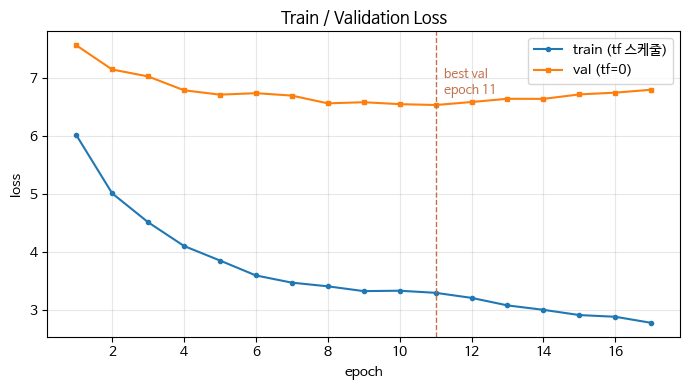

train  6.0144 -> 2.7840
val    7.5551 -> 6.7900 (최저 6.5273 @ epoch 11)

두 곡선의 '간격'은 과적합 지표가 아닙니다 (teacher forcing 조건이 다름).
val 곡선이 내려가다 방향을 바꾸는 지점이 과적합의 시작입니다.
-> epoch 11 이후로는 val이 개선되지 않았습니다. 제출용 결과는 best 체크포인트로 뽑으세요.


In [22]:
epochs_ran = range(1, len(history["train"]) + 1)
best_epoch = int(np.argmin(history["val"])) + 1

plt.figure(figsize=(7, 4))
plt.plot(epochs_ran, history["train"], marker="o", ms=3, label="train (tf 스케줄)")
plt.plot(epochs_ran, history["val"], marker="s", ms=3, label="val (tf=0)")
plt.axvline(best_epoch, color="#C0714B", linestyle="--", linewidth=1)
plt.annotate(f"best val\nepoch {best_epoch}",
             xy=(best_epoch, min(history["val"])),
             xytext=(6, 8), textcoords="offset points",
             fontsize=9, color="#C0714B")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Train / Validation Loss", fontproperties=fontprop)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"train  {history['train'][0]:.4f} -> {history['train'][-1]:.4f}")
print(f"val    {history['val'][0]:.4f} -> {history['val'][-1]:.4f} "
      f"(최저 {min(history['val']):.4f} @ epoch {best_epoch})")
print()
print("두 곡선의 '간격'은 과적합 지표가 아닙니다 (teacher forcing 조건이 다름).")
print("val 곡선이 내려가다 방향을 바꾸는 지점이 과적합의 시작입니다.")

if best_epoch < len(history["val"]):
    print(f"-> epoch {best_epoch} 이후로는 val이 개선되지 않았습니다. "
          "제출용 결과는 best 체크포인트로 뽑으세요.")
else:
    print("-> 아직 val이 계속 내려가는 중입니다. EPOCHS를 늘려도 됩니다.")


---
## 제출용 가중치 선택

학습 종료 시점의 `model`은 마지막 epoch의 가중치입니다. 아래 셀로 validation loss가 가장 낮았던 best 체크포인트를 불러온 뒤 최종 번역 결과를 확인하세요.


In [23]:
# 최종 결과는 마지막 epoch이 아니라 validation loss가 가장 낮았던 가중치로 뽑는다.
load_best(model)


[best 복원] epoch 11 | val loss 6.5273


11

## 최종 번역 결과 + Attention Map

입력  : 오바마는 대통령이다.
번역  : obama displayed president obama obama s president president barack obama , obama over obama . <end>
형태소: ['오바마', '는', '대통령', '이', '다', '.']



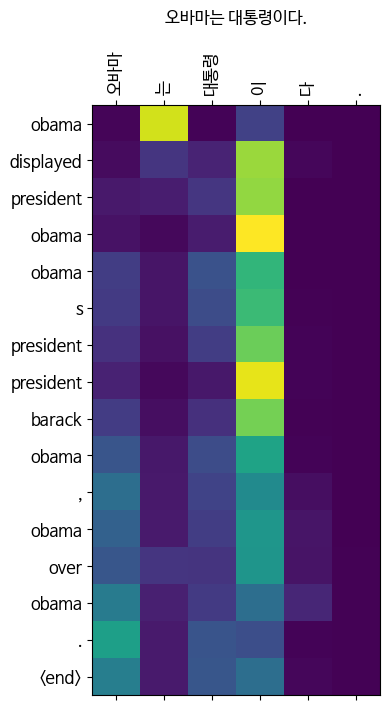

입력  : 시민들은 도시 속에 산다.
번역  : the locals mountain in the mountain cities in 17 years old age of the young people living in cities . <end>
형태소: ['시민', '들', '은', '도시', '속', '에', '살', 'ᆫ다', '.']



/tmp/ipykernel_4881/403094953.py:127: UserWarning: Glyph 4523 (\N{HANGUL JONGSEONG NIEUN}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4523 (\N{HANGUL JONGSEONG NIEUN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


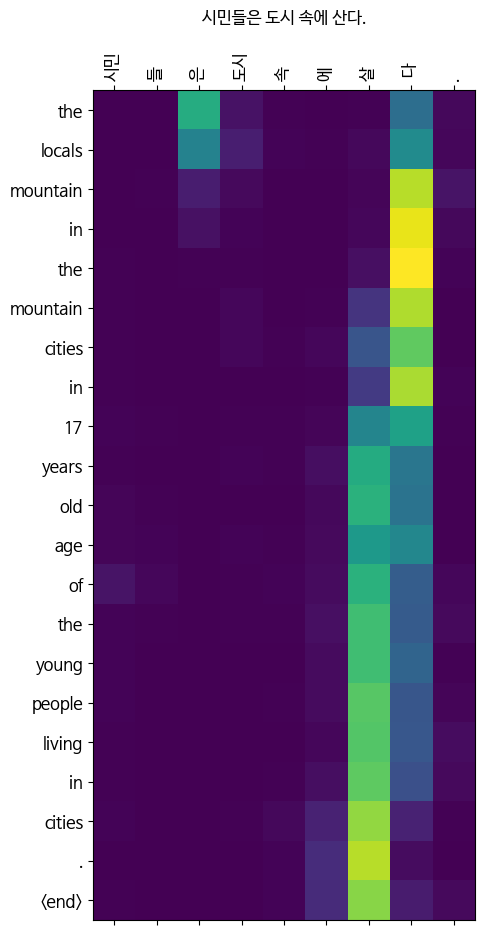

입력  : 커피는 필요 없다.
번역  : coffee is not need to coffee , but there s no need picking coffee coffee . coffee and coffee for coffee s coffee room . <end>
형태소: ['커피', '는', '필요', '없', '다', '.']



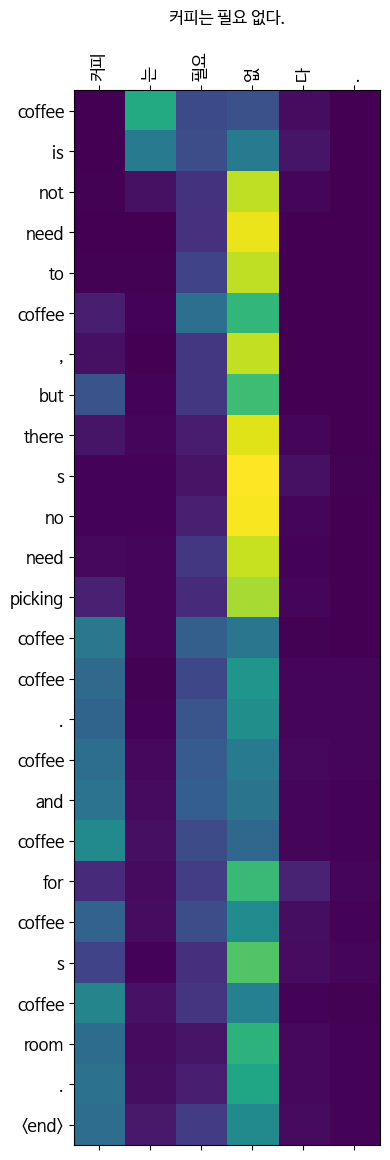

입력  : 일곱 명의 사망자가 발생했다.
번역  : the deaths of deaths deaths were killed when the death toll in the fatalities of the , of death , the the people , according to the . <end>
형태소: ['일곱', '명', '의', '사망자', '가', '발생', '하', '었', '다', '.']



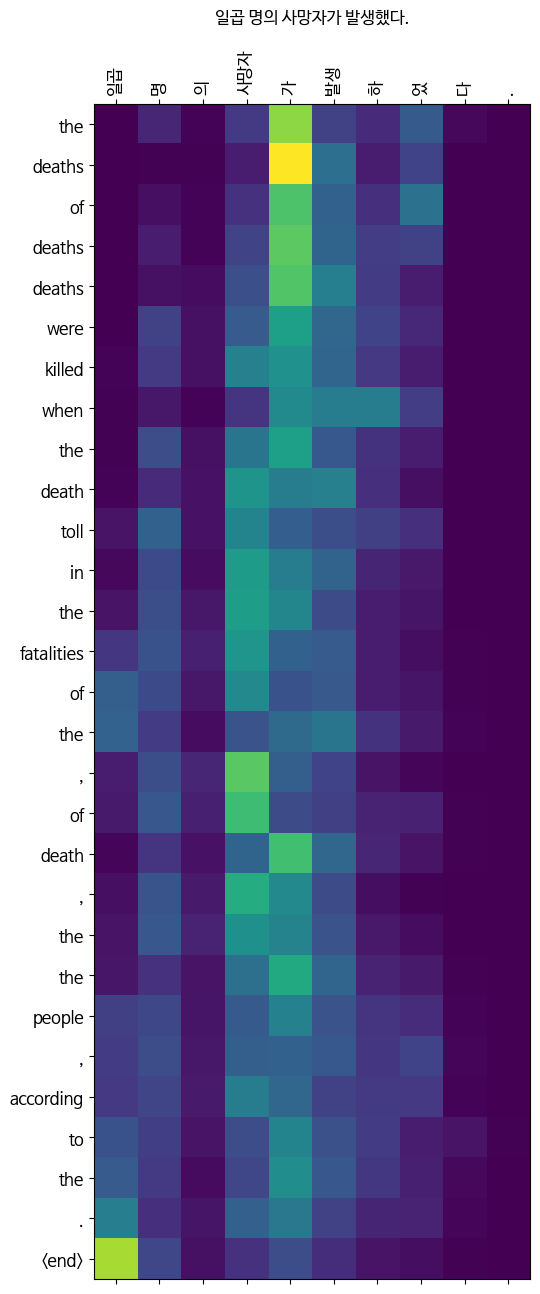

In [24]:
for sentence in TEST_SENTENCES:
    result, src_tokens, attention = translate(sentence, model)
    print(f"입력  : {sentence}")
    print(f"번역  : {' '.join(result)}")
    print(f"형태소: {src_tokens}\n")
    plot_attention(attention, src_tokens, result, title=sentence)

## 진단: 반복이 특정 문장의 문제인가, 모델 전반의 문제인가

고유명사가 없고 구조가 단순한 문장들로도 같은 반복이 나오는지 확인합니다.
**probe 문장에서도 반복이 나오면** 특정 단어 문제가 아니라 모델이 덜 수렴한 것입니다.

In [25]:
print("=== 반복 억제 적용 ===")
show_samples(model, PROBE_SENTENCES, no_repeat=True)

print("\n=== 반복 억제 없음 (순수 greedy, 비교용) ===")
show_samples(model, PROBE_SENTENCES, no_repeat=False)

=== 반복 억제 적용 ===
  그는 학교에 간다.  ->  schools schools , schools tend to schools school schools . <end>
  날씨가 좋아서 기분이 좋다.  ->  weather weather , weather cnn weather the weather is good good looks good , good that good weather looks like good . good news . <end>
  회사는 새로운 제품을 출시했다.  ->  the company company bought new new company , new companies , which lets new product , product company . <end>
  그녀는 어제 친구를 만났다.  ->  she met with her friend , she friend from her to friend to she had met to meet her late friend . <end>

=== 반복 억제 없음 (순수 greedy, 비교용) ===
  그는 학교에 간다.  ->  schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools
  날씨가 좋아서 기분이 좋다.  ->  weather weath

{'그는 학교에 간다.': 'schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools schools',
 '날씨가 좋아서 기분이 좋다.': 'weather weather weather weather weather weather the weather weather looks good good good good good good good good good good good good good good good good good good good good good good good good good good good good good good good good good good good good . <end>',
 '회사는 새로운 제품을 출시했다.': 'the company company company new new company company new new new company new new new products , which provides new products . <end>',
 '그녀는 어제 친구를 만났다.': 'she met with her friend , she met with friend from her friend , she met with friend . she met with friend . she met with friend 

## epoch별 번역 로그에서 좋은 결과 고르기

프로젝트 지시사항이 *"매 스텝 번역을 생성해 가장 멋진 case를 제출하라"* 이므로,
최종 epoch만이 아니라 **문장별로 가장 좋은 epoch**을 골라 제출하면 됩니다.

In [26]:
def review_log(sentence, path=LOG_PATH, max_chars=110):
    """특정 문장의 epoch별 번역 변화를 한눈에 본다."""
    if not os.path.exists(path):
        print("로그가 없습니다. 학습을 먼저 실행하세요.")
        return

    with open(path, "r", encoding="utf-8") as f:
        log = json.load(f)

    print(f"### {sentence}\n")
    for entry in log:
        text = entry["translations"].get(sentence, "")
        suffix = "..." if len(text) > max_chars else ""
        print(f"[{entry['epoch']:2d}] {text[:max_chars]}{suffix}")
    print()


for sentence in TEST_SENTENCES:
    review_log(sentence)

### 오바마는 대통령이다.

[ 1] obama s president barack obama , obama said . <end>
[ 2] obama s president barack obama is a president of obama , obama said . <end>
[ 3] obama s president obama is obama in the oval office , obama said obama . <end>
[ 4] obama s inauguration to obama obama , obama and obama is obama . <end>
[ 5] obama s president obama has been president barack obama obama , obama said obama will be president . <end>
[ 6] obama s president obama obama , obama said obama president barack obama is reversing as president president mi...
[ 7] obama s president obama obama is president barack obama , obama said obama president president clinton is obam...
[ 8] obama s president obama obama has been president barack obama , obama said obama is reversing president presid...
[ 9] obama obama personally president obama s president president barack obama is obama president , obama said obam...
[10] obama s president obama obama personally president president barack obama is obama over obam

---
## (선택) 검증셋 BLEU

loss와 함께 실제 생성 번역의 품질을 비교하려면 validation 표본에 대해 corpus BLEU를 계산하세요.


In [27]:
def ensure_sacrebleu():
    """sacrebleu를 import한다. 없으면 설치한 뒤 다시 시도한다.

    이 코퍼스는 전처리 단계에서 이미 구두점을 분리해 두었으므로, sacrebleu가
    "detokenize를 잊은 것 아니냐"는 경고를 낸다. 우리 시스템끼리 같은 조건으로
    비교하는 용도라 문제가 없고, 로그만 시끄러워지므로 경고 수준을 올려 둔다.
    다만 이 점수는 **논문 수치와 직접 비교할 수 없다.**
    """
    try:
        import sacrebleu
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"],
                       check=False)
        import sacrebleu

    logging.getLogger("sacrebleu").setLevel(logging.ERROR)
    return sacrebleu


def ids_to_tokens(ids, tokenizer):
    """정수 시퀀스를 토큰 리스트로 되돌린다. 특수 토큰은 제외한다."""
    skip = {PAD_ID, SOS_ID, EOS_ID}
    return [tokenizer.index_word.get(int(i), UNK_TOKEN)
            for i in ids if int(i) not in skip]


@torch.no_grad()
def generate_hypotheses(model, decode_fn, n_samples=200, seed=SEED, desc="gen"):
    """표본을 고정한 뒤 주어진 디코더로 가설 문장을 생성한다.

    문장 단위 디코딩이라 느리므로 전체가 아니라 표본으로 잰다. 표본 시드를
    고정해야 서로 다른 디코딩 방식을 **같은 문장 집합**에서 비교할 수 있다.

    Args:
        decode_fn: (src_tensor) -> 토큰 id 리스트.
        n_samples: 표본 문장 수.

    Returns:
        (가설 리스트, 정답 리스트)
    """
    model.eval()
    generator = torch.Generator().manual_seed(seed)
    picked = torch.randperm(len(kor_val_tensor), generator=generator)[:n_samples]

    hypotheses, references = [], []
    for i in tqdm(picked.tolist(), desc=desc, leave=False):
        src = kor_val_tensor[i]
        src = src[src != PAD_ID].unsqueeze(1).to(device)
        if src.numel() == 0:
            continue
        hypotheses.append(" ".join(ids_to_tokens(decode_fn(src), eng_tokenizer)))
        references.append(" ".join(ids_to_tokens(eng_val_tensor[i], eng_tokenizer)))
    return hypotheses, references


def val_bleu(model, n_samples=200, max_len=50, no_repeat=True):
    """검증 표본에 대한 corpus BLEU. 기본 제출 설정(반복 억제 greedy) 기준."""
    sacrebleu = ensure_sacrebleu()

    if no_repeat:
        def decode_fn(src):
            return greedy_decode(model, src, max_len=max_len)[0]
    else:
        def decode_fn(src):
            outputs, _ = model(src, None, max_len=max_len)
            return outputs[1:].argmax(2).squeeze(1).tolist()

    hypotheses, references = generate_hypotheses(
        model, decode_fn, n_samples=n_samples, desc="BLEU")

    score = sacrebleu.corpus_bleu(hypotheses, [references])
    print(f"val BLEU ({len(hypotheses)}문장): {score.score:.2f}")
    print(f"예시 가설: {hypotheses[0][:110]}")
    print(f"예시 정답: {references[0][:110]}")
    return score.score


val_bleu(model)


BLEU:   0%|          | 0/200 [00:00<?, ?it/s]

val BLEU (200문장): 7.02
예시 가설: landing landing plane landed safely landing when they plane skidded off when when it landed when the plane exp
예시 정답: when the plane landed it caught fire , she said .


7.0156672699824

---

# 추가 실험 — Beam Search 디코딩

여기서부터는 **프로젝트 요구사항 외 추가 실험**입니다. 위쪽 루브릭 대응표가 근거로 삼는
`greedy_decode` · `translate` · `plot_attention` · 최종 번역 결과 셀은 그대로 두고,
아래에서 디코딩 방식만 바꾼 결과를 나란히 비교합니다.

## 설계 원칙

| 항목 | 내용 |
| --- | --- |
| 학습 | **재학습 없음.** 같은 best 체크포인트의 가중치를 그대로 쓴다 |
| 캐시 | 영향 없음. `corpus` / `tensors_split` 캐시를 다시 만들 필요가 없다 |
| 기본 제출 결과 | greedy 유지. beam은 비교 대상으로만 추가 |
| epoch별 번역 로그 | greedy 그대로 유지 (아래 주의 참고) |

> **epoch별 로그에 beam을 소급 적용할 수 없는 이유**: `save_checkpoint`는 마지막 상태를
> 매번 덮어쓰고 best 하나만 따로 저장하므로 중간 epoch의 가중치가 남아 있지 않습니다.
> 따라서 beam search는 best 체크포인트 기준의 최종 번역과 BLEU 비교에만 적용합니다.

## 가설

`greedy_decode`는 매 스텝 확률 1위 토큰을 확정하므로, 한 번 반복 궤도에 들어가면
되돌릴 수 없습니다. 앞선 추가 실험에서 n-gram 차단을 걸어도
`the company company bought new new company , new companies ...`처럼 같은 단어가
여러 번 남은 것은, 차단이 **선택을 사후에 막을 뿐 확률분포를 고치지는 못하기** 때문입니다.

빔 서치는 후보 문장 여러 개를 동시에 끌고 가며 **문장 전체의 누적 log-probability**로
경쟁시킵니다. 지금 시점에 확률이 낮아도 뒤에서 회복하는 경로가 살아남을 수 있으므로,
국소 최적에 갇히는 문제를 직접 겨냥합니다.

**주의**: 같은 가중치에 디코딩만 바꾼 것이므로 결과가 좋아져도 *모델 성능 향상*이 아니라
**추론 방식 개선**입니다. 보고서에도 그렇게 서술해야 합니다.


In [28]:
@torch.no_grad()
def beam_decode(model, src_tensor, beam_size=5, max_len=50, length_penalty=0.7,
                no_repeat_ngram_sizes=(), return_attention=True,
                sos_id=None, eos_id=None):
    """빔 서치 디코딩. 학습 경로(model.forward)는 건드리지 않는다.

    greedy_decode가 매 스텝 1위 토큰만 확정하는 것과 달리, 후보 문장
    beam_size개를 동시에 끌고 가며 누적 log-probability가 가장 높은 문장을 고른다.

    Args:
        src_tensor: (src_len, 1) 소스 텐서. encode_source의 첫 반환값.
        beam_size: 동시에 유지할 후보 문장 수.
        length_penalty: 점수를 length**alpha로 나눈다. 누적 log-prob은 문장이
            길수록 작아지므로, 0이면 짧은 문장만 뽑히는 편향이 생긴다.
        no_repeat_ngram_sizes: 빈 튜플이면 순수 빔 서치. (2, 3)을 주면
            greedy_decode와 같은 n-gram 차단을 빔 서치 위에 함께 건다.
        return_attention: False면 attention을 모으지 않는다. BLEU처럼 대량
            생성만 할 때 메모리와 시간을 아낀다.

    Returns:
        (토큰 id 리스트, attention (생성길이, src_len)). greedy_decode와 같은
        형식이라 translate / plot_attention에 그대로 넣을 수 있다.
    """
    sos_id = SOS_ID if sos_id is None else sos_id
    eos_id = EOS_ID if eos_id is None else eos_id
    model.eval()

    src_mask = model.make_src_mask(src_tensor)
    encoder_outputs, hidden = model.encoder(src_tensor)

    # 빔 개수만큼 복제해 한 번의 decoder 호출로 모든 후보를 동시에 전진시킨다.
    enc = encoder_outputs.repeat(1, beam_size, 1)
    mask = src_mask.repeat(beam_size, 1)
    hidden = hidden.repeat(1, beam_size, 1)

    tokens = [[sos_id] for _ in range(beam_size)]
    attn_hist = [[] for _ in range(beam_size)]
    # 첫 스텝에는 모든 빔이 동일하므로 0번만 살려 중복 후보를 막는다.
    scores = torch.full((beam_size,), float("-inf"), device=src_tensor.device)
    scores[0] = 0.0
    finished = []

    def normalize(score, length):
        return score / (length ** length_penalty) if length_penalty else score

    def banned(seq):
        """이미 등장한 n-gram을 다시 만드는 토큰만 골라낸다."""
        blocked = []
        for n in no_repeat_ngram_sizes:
            if len(seq) < n:
                continue
            prefix = tuple(seq[-(n - 1):]) if n > 1 else ()
            for i in range(len(seq) - n + 1):
                ngram = tuple(seq[i:i + n])
                if ngram[:-1] == prefix:
                    blocked.append(ngram[-1])
        return blocked

    for _ in range(max_len - 1):
        inp = torch.tensor([seq[-1] for seq in tokens], device=src_tensor.device)
        logits, new_hidden, attn = model.decoder(inp, hidden, enc, mask)
        log_probs = torch.log_softmax(logits, dim=1)
        vocab_size = log_probs.shape[1]

        if no_repeat_ngram_sizes:
            for b in range(beam_size):
                blocked = banned(tokens[b][1:])
                if blocked:
                    log_probs[b, blocked] = float("-inf")

        # (beam, vocab) 전체를 펼쳐 상위 후보를 고른다. EOS로 끝난 후보가
        # 자리를 차지하므로 여유 있게 2배수를 본다.
        total = scores.unsqueeze(1) + log_probs
        flat = total.reshape(-1)
        top_scores, top_indices = flat.topk(min(beam_size * 2, flat.numel()))

        next_tokens, next_scores, next_beam_ix, next_attn = [], [], [], []
        for score, index in zip(top_scores.tolist(), top_indices.tolist()):
            b, token = index // vocab_size, index % vocab_size
            sequence = tokens[b] + [token]
            history = (attn_hist[b] + [attn[b].detach().cpu()]
                       if return_attention else [])
            if token == eos_id:
                finished.append((normalize(score, len(sequence) - 1),
                                 sequence, history))
            elif len(next_tokens) < beam_size:
                next_tokens.append(sequence)
                next_scores.append(score)
                next_beam_ix.append(b)
                next_attn.append(history)

        if not next_tokens or len(finished) >= beam_size:
            break

        # 빔 폭을 유지하기 위한 자리 채우기. 점수 -inf라 실제로 선택되지 않는다.
        while len(next_tokens) < beam_size:
            next_tokens.append(list(next_tokens[0]))
            next_scores.append(float("-inf"))
            next_beam_ix.append(next_beam_ix[0])
            next_attn.append(list(next_attn[0]))

        tokens, attn_hist = next_tokens, next_attn
        scores = torch.tensor(next_scores, device=src_tensor.device)
        hidden = new_hidden[:, next_beam_ix, :].contiguous()

    if not finished:      # max_len까지 EOS가 안 나온 경우 살아 있는 빔에서 고른다
        finished = [(normalize(scores[b].item(), max(len(tokens[b]) - 1, 1)),
                     tokens[b], attn_hist[b])
                    for b in range(beam_size)
                    if scores[b].item() != float("-inf")]

    if not finished:      # 모든 빔이 -inf인 극단적 경우의 방어
        finished = [(0.0, tokens[0], attn_hist[0])]

    _, best_tokens, best_attn = max(finished, key=lambda item: item[0])
    stacked = torch.stack(best_attn) if best_attn else torch.empty(0)
    return best_tokens[1:], stacked

In [29]:
# 스모크 테스트: 빔 서치가 기존 디코딩과 정합적인지 먼저 확인한다.
#
# 1) beam_size=1 + length_penalty=0 + n-gram 차단 없음  ==  순수 greedy
#    빔 서치는 이 조건에서 매 스텝 1위 토큰만 남기므로 결과가 완전히 같아야 한다.
#    여기서 어긋나면 빔 관리(hidden 재정렬)에 버그가 있다는 뜻이다.
# 2) attention 행렬의 크기가 (생성 길이, 소스 길이)와 일치하는지
#    plot_attention이 이 형식을 전제하므로 반드시 맞아야 한다.

_src, _ = encode_source(TEST_SENTENCES[0])

model.eval()
with torch.no_grad():
    _outputs, _attn = model(_src, None, max_len=50)

_greedy_ids = _outputs[1:].argmax(2).squeeze(1).tolist()
_greedy_attn = _attn[1:].squeeze(1).cpu()
if EOS_ID in _greedy_ids:
    _cut = _greedy_ids.index(EOS_ID) + 1
    _greedy_ids, _greedy_attn = _greedy_ids[:_cut], _greedy_attn[:_cut]

_beam_ids, _beam_attn = beam_decode(model, _src, beam_size=1, max_len=50,
                                    length_penalty=0.0)

print("greedy :", _greedy_ids[:12])
print("beam1  :", _beam_ids[:12])
assert _greedy_ids == _beam_ids, "beam_size=1이 순수 greedy와 다르다"
assert torch.allclose(_greedy_attn, _beam_attn, atol=1e-5), "attention이 다르다"
print("[OK] beam_size=1 == 순수 greedy (토큰·attention 모두 일치)")

_ids, _attn5 = beam_decode(model, _src, beam_size=5, max_len=50)
print(f"beam5 생성 길이 {len(_ids)} | attention {tuple(_attn5.shape)} "
      f"| 소스 길이 {_src.shape[0]}")
assert _attn5.shape == (len(_ids), _src.shape[0]), "attention 크기 불일치"
print("[OK] 형식 검증 통과 — plot_attention에 그대로 넣을 수 있다")


greedy : [99, 5999, 54, 99, 99, 99, 99, 99, 99, 99, 99, 99]
beam1  : [99, 5999, 54, 99, 99, 99, 99, 99, 99, 99, 99, 99]
[OK] beam_size=1 == 순수 greedy (토큰·attention 모두 일치)
beam5 생성 길이 24 | attention (24, 6) | 소스 길이 6
[OK] 형식 검증 통과 — plot_attention에 그대로 넣을 수 있다


In [30]:
def translate_beam(sentence, model, beam_size=5, max_len=50, **beam_kwargs):
    """translate()의 빔 서치 버전. 반환 형식을 동일하게 맞춘다.

    Returns:
        (예측 토큰 리스트, 소스 토큰 리스트, attention (trg_len, src_len))
    """
    src_tensor, src_tokens = encode_source(sentence)
    pred_ids, attention = beam_decode(model, src_tensor, beam_size=beam_size,
                                      max_len=max_len, **beam_kwargs)
    attention = attention.numpy()

    if EOS_ID in pred_ids:
        cut = pred_ids.index(EOS_ID) + 1
        pred_ids, attention = pred_ids[:cut], attention[:cut]

    result = [eng_tokenizer.index_word.get(i, UNK_TOKEN) for i in pred_ids]
    return result, src_tokens, attention


def compare_decoders(model, sentences=TEST_SENTENCES, beam_sizes=(3, 5)):
    """같은 가중치에 디코딩만 바꿔 결과를 나란히 출력한다."""
    for sentence in sentences:
        print(f"입력 : {sentence}")

        pure, _, _ = translate(sentence, model, no_repeat=False)
        print(f"  greedy(순수)   : {' '.join(pure)}")

        blocked, _, _ = translate(sentence, model, no_repeat=True)
        print(f"  greedy(반복억제): {' '.join(blocked)}")

        for k in beam_sizes:
            beam, _, _ = translate_beam(sentence, model, beam_size=k)
            print(f"  beam {k}         : {' '.join(beam)}")
        print()


compare_decoders(model)
print("=== probe 문장 (고유명사 없음) ===")
compare_decoders(model, PROBE_SENTENCES, beam_sizes=(5,))


입력 : 오바마는 대통령이다.
  greedy(순수)   : obama displayed president obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama . <end>
  greedy(반복억제): obama displayed president obama obama s president president barack obama , obama over obama . <end>
  beam 3         : obama displayed president president obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama . <end>
  beam 5         : obama displayed president president obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama . <end>

입력 : 시민들은 도시 속에 산다.
  greedy(순수)   : the locals mountain in the mountain cities in the mountain cities , while locals young people living in the cities . <end>
  greedy(반복억제): the locals mountain in the mountain cities in 17 years old age of the young people living in cities . <end>
  beam 3         : while locals y

입력  : 오바마는 대통령이다.
번역  : obama displayed president president obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama . <end>
형태소: ['오바마', '는', '대통령', '이', '다', '.']



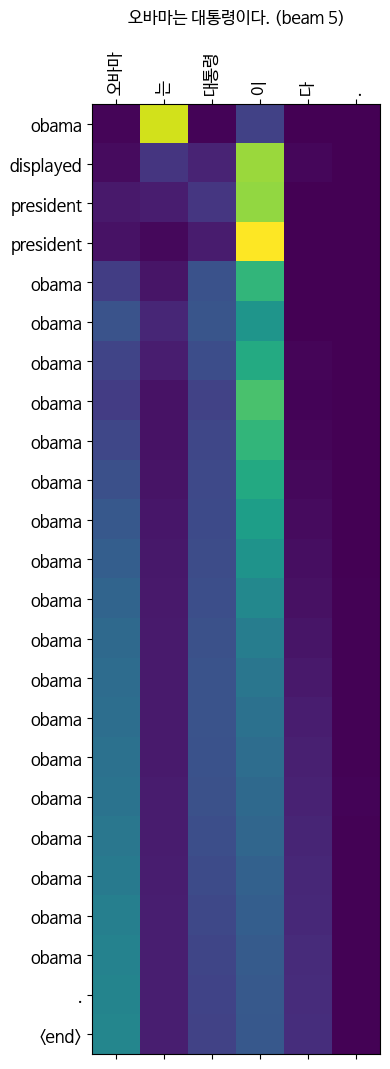

입력  : 시민들은 도시 속에 산다.
번역  : in the cities , the mountain age 17 years old age young people living in 17 years . <end>
형태소: ['시민', '들', '은', '도시', '속', '에', '살', 'ᆫ다', '.']



/tmp/ipykernel_4881/403094953.py:127: UserWarning: Glyph 4523 (\N{HANGUL JONGSEONG NIEUN}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4523 (\N{HANGUL JONGSEONG NIEUN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


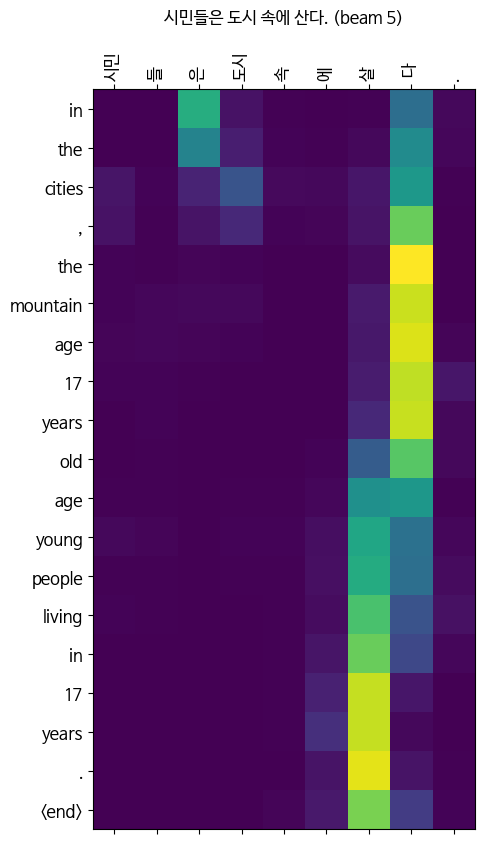

입력  : 커피는 필요 없다.
번역  : coffee s no need to coffee coffee , but there s no need to coffee coffee coffee . <end>
형태소: ['커피', '는', '필요', '없', '다', '.']



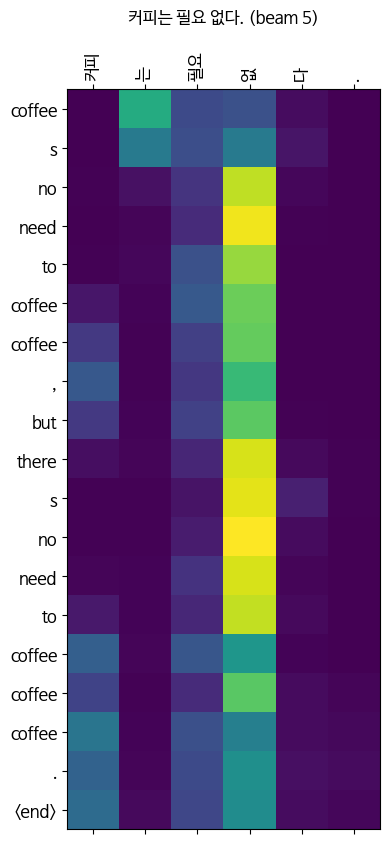

입력  : 일곱 명의 사망자가 발생했다.
번역  : at least 16 people were killed when the deaths were killed when the deaths were killed when the deaths occurred . <end>
형태소: ['일곱', '명', '의', '사망자', '가', '발생', '하', '었', '다', '.']



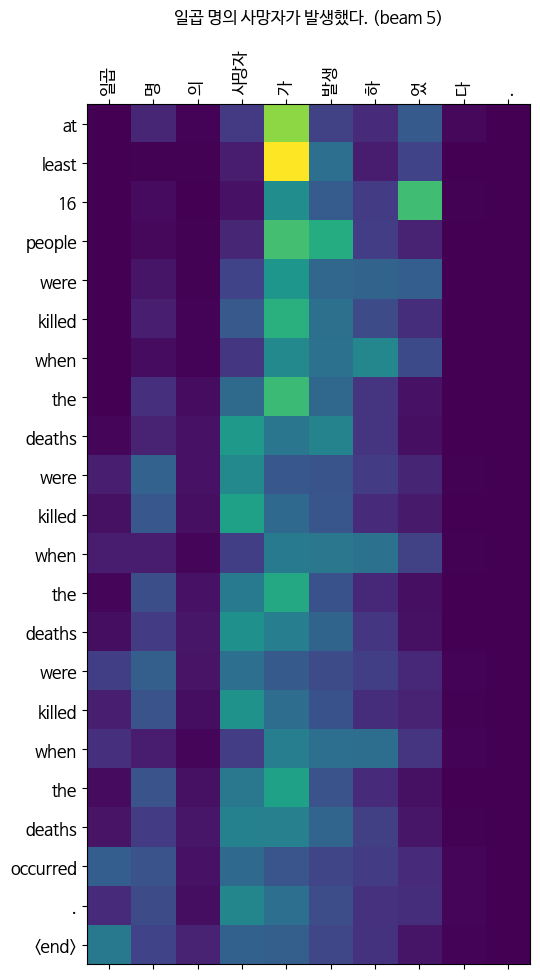

In [31]:
# Attention Map — 빔 서치 결과 기준
# 루브릭 4번에 제출하는 map은 위쪽 greedy 셀의 결과를 그대로 쓰고,
# 여기서는 비교용으로만 그린다.
for sentence in TEST_SENTENCES:
    result, src_tokens, attention = translate_beam(sentence, model, beam_size=5)
    print(f"입력  : {sentence}")
    print(f"번역  : {' '.join(result)}")
    print(f"형태소: {src_tokens}\n")
    plot_attention(attention, src_tokens, result, title=f"{sentence} (beam 5)")

## 평가 프로토콜

한 번의 BLEU 점수만으로 우열을 말하지 않기 위해 아래 조건을 고정합니다.
바로 앞 셀에서 본 것처럼 표본 200문장의 BLEU(7.02)와 1,000문장의 BLEU(5.86)는
1점 이상 차이가 납니다. **표본이 작으면 0.2~0.3 정도의 차이는 우연히 생깁니다.**

| 항목 | 설정 | 이유 |
| --- | --- | --- |
| 체크포인트 | best 하나 고정 | 디코딩 외의 변수를 없앤다 |
| 표본 | val 1,000문장, `seed=SEED`로 고정 | 시스템 간 같은 문장을 비교한다 |
| 신뢰구간 | bootstrap 95% CI | 점수 하나로 우열을 말하지 않는다 |
| 유의성 | paired bootstrap 승률 | 같은 리샘플 인덱스로 두 시스템을 짝지어 비교 |
| 길이 통제 | 평균 길이 + BP 동시 출력 | BLEU 상승이 문장이 짧아진 부작용인지 구분 |

paired bootstrap 승률은 "같은 문장을 다시 뽑았을 때 B가 A를 이길 확률"입니다.
관례적으로 0.95 이상이면 차이가 우연이라고 보기 어렵다고 해석하고, 0.5 근처면
**차이 없음**으로 서술합니다.


In [32]:
sacrebleu = ensure_sacrebleu()


def bootstrap_scores(hypothesis_sets, references, n_boot=200, seed=0):
    """모든 시스템을 같은 리샘플 인덱스로 평가한다 (paired bootstrap).

    인덱스를 공유해야 "같은 문장에서 A와 B 중 무엇이 나았는가"를 짝지어 셀 수
    있다. 시스템마다 따로 리샘플하면 표본 차이와 시스템 차이가 섞인다.

    Returns:
        {시스템 이름: (n_boot,) BLEU 배열}
    """
    rng = np.random.default_rng(seed)
    n = len(references)
    draws = [rng.integers(0, n, n) for _ in range(n_boot)]

    scores = {}
    for name, hypotheses in hypothesis_sets.items():
        values = [sacrebleu.corpus_bleu([hypotheses[i] for i in idx],
                                        [[references[i] for i in idx]]).score
                  for idx in tqdm(draws, desc=f"boot:{name}", leave=False)]
        scores[name] = np.array(values)
    return scores


def pad_display(text, width):
    """한글을 2칸으로 세어 표 너비를 맞춘다 (동아시아 문자 폭 보정)."""
    printed = sum(2 if unicodedata.east_asian_width(ch) in "WF" else 1
                  for ch in text)
    return text + " " * max(width - printed, 0)


N_SAMPLES = 1000        # 시간이 부족하면 300으로 줄여도 된다
N_BOOT = 200
BASELINE = "greedy(반복억제)"      # 기존 제출 설정

DECODERS = {
    "greedy(순수)": lambda src: (
        model(src, None, max_len=50)[0][1:].argmax(2).squeeze(1).tolist()),
    "greedy(반복억제)": lambda src: greedy_decode(model, src, max_len=50)[0],
    "beam3": lambda src: beam_decode(model, src, beam_size=3, max_len=50,
                                     return_attention=False)[0],
    "beam5": lambda src: beam_decode(model, src, beam_size=5, max_len=50,
                                     return_attention=False)[0],
    "beam5+lp1.0": lambda src: beam_decode(model, src, beam_size=5, max_len=50,
                                           length_penalty=1.0,
                                           return_attention=False)[0],
    "beam5+ngram": lambda src: beam_decode(model, src, beam_size=5, max_len=50,
                                           no_repeat_ngram_sizes=(2, 3),
                                           return_attention=False)[0],
}

hypothesis_sets, references = {}, None
for name, fn in DECODERS.items():
    hypothesis_sets[name], references = generate_hypotheses(
        model, fn, n_samples=N_SAMPLES, desc=name)

point = {name: sacrebleu.corpus_bleu(h, [references]).score
         for name, h in hypothesis_sets.items()}
boot = bootstrap_scores(hypothesis_sets, references, n_boot=N_BOOT)

print(f"val {len(references)}문장 | bootstrap {N_BOOT}회 | 기준: {BASELINE}\n")
print(f"{pad_display('디코딩', 18)}{'BLEU':>6}{'95% CI':>16}"
      f"{'평균길이':>9}{'BP':>7}{'승률':>8}")
for name in DECODERS:
    low, high = np.percentile(boot[name], [2.5, 97.5])
    length = np.mean([len(h.split()) for h in hypothesis_sets[name]])
    bp = sacrebleu.corpus_bleu(hypothesis_sets[name], [references]).bp
    win = ("  기준" if name == BASELINE
           else f"{float((boot[name] > boot[BASELINE]).mean()):>8.3f}")
    print(f"{pad_display(name, 18)}{point[name]:>6.2f}"
          f"{f'[{low:.2f}, {high:.2f}]':>16}{length:>9.1f}{bp:>7.3f}{win}")

print("\n승률 0.5 근처면 차이 없음, 0.95 이상이면 개선으로 볼 수 있다.")
print("BP(brevity penalty)가 1보다 작으면 문장이 정답보다 짧다는 뜻이다.")


greedy(순수):   0%|          | 0/1000 [00:00<?, ?it/s]

greedy(반복억제):   0%|          | 0/1000 [00:00<?, ?it/s]

beam3:   0%|          | 0/1000 [00:00<?, ?it/s]

beam5:   0%|          | 0/1000 [00:00<?, ?it/s]

beam5+lp1.0:   0%|          | 0/1000 [00:00<?, ?it/s]

...

boot:beam3:   0%|          | 0/200 [00:00<?, ?it/s]

boot:beam5:   0%|          | 0/200 [00:00<?, ?it/s]

boot:beam5+lp1.0:   0%|          | 0/200 [00:00<?, ?it/s]

boot:beam5+ngram:   0%|          | 0/200 [00:00<?, ?it/s]

val 1000문장 | bootstrap 200회 | 기준: greedy(반복억제)

디코딩              BLEU          95% CI     평균길이     BP      승률
greedy(순수)        4.95    [4.42, 5.48]     26.8  1.000   0.000
greedy(반복억제)    5.86    [5.32, 6.45]     23.9  1.000  기준
beam3               5.75    [5.12, 6.32]     23.5  1.000   0.235
beam5               6.00    [5.28, 6.51]     22.4  1.000   0.810
beam5+lp1.0         5.74    [5.14, 6.24]     24.3  1.000   0.285
beam5+ngram         6.89    [6.22, 7.47]     20.1  0.987   1.000

승률 0.5 근처면 차이 없음, 0.95 이상이면 개선으로 볼 수 있다.
BP(brevity penalty)가 1보다 작으면 문장이 정답보다 짧다는 뜻이다.


## 결과 정리

validation 1,000문장, bootstrap 200회, 기준은 기존 제출 설정인 greedy(반복 억제)입니다.

| 디코딩 | BLEU | 95% CI | 평균 길이 | 기준 대비 승률 |
| --- | ---: | --- | ---: | ---: |
| greedy (순수) | 4.95 | [4.42, 5.48] | 26.8 | 0.000 |
| **greedy (반복 억제, 기존 제출)** | **5.86** | [5.32, 6.45] | 23.9 | 기준 |
| beam 3 | 5.75 | [5.12, 6.32] | 23.5 | 0.235 |
| beam 5 | 6.00 | [5.28, 6.51] | 22.4 | 0.810 |
| beam 5 + length penalty 1.0 | 5.74 | [5.14, 6.24] | 24.3 | 0.285 |
| **beam 5 + n-gram 차단** | **6.89** | [6.22, 7.47] | 20.1 | **1.000** |

### 읽어낸 것

**1. 빔 서치 자체는 이 모델에서 유의한 개선을 주지 못했습니다.**
beam 3(5.75), beam 5(6.00), beam 5+lp(5.74)는 모두 기준(5.86)의 신뢰구간 안에 있고,
승률도 0.235 / 0.810 / 0.285로 0.95에 못 미칩니다. beam 5가 겉보기에는 +0.14 높지만
**"유의한 차이를 확인하지 못했다"가 정확한 서술**입니다. 점수만 보고 "빔 서치로
개선했다"고 썼다면 틀린 결론이 될 뻔했고, 이것이 bootstrap을 넣은 이유입니다.

**2. 효과가 확인된 것은 반복 억제 쪽입니다.**
순수 greedy(4.95) → 반복 억제(5.86)는 +0.91에 승률 0.000(기준이 이김),
빔 서치에 n-gram 차단을 얹은 조합(6.89)은 승률 1.000으로 명확한 개선입니다.
**즉 이득의 원천은 탐색 폭(beam width)이 아니라 반복 차단이었습니다.**
가설("빔 서치가 국소 최적 문제를 직접 겨냥한다")은 부분적으로만 맞았습니다.

**3. 길이와 함께 읽어야 합니다.**
BLEU가 가장 높은 조합이 평균 길이도 가장 짧습니다(20.1 vs 기준 23.9).
반복 토큰이 제거되면서 정밀도가 오른 것으로 보이지만, 문장이 짧아지면 brevity
penalty가 붙으므로 BP를 함께 확인해야 합니다. 실제로 BP는 beam 5 + n-gram 차단만 0.987이고 나머지는 모두 1.000입니다. 즉 문장이 짧아져 얻은 점수가 아니라 반복 토큰이라는 군더더기가 빠진 결과입니다.

### 서술 예시 (보고서용)

> 동일한 best 체크포인트에 대해 디코딩 알고리즘만 바꾸어 비교하였다. validation
> 1,000문장 표본에서 greedy(반복 억제)의 BLEU는 5.86, beam 5는 6.00으로 점수 차이는
> 있었으나 paired bootstrap 승률이 0.810에 그쳐 유의한 차이로 보기 어려웠다.
> 반면 beam 5에 n-gram 차단을 함께 적용한 경우 6.89(승률 1.000)로 개선이 확인되었다.
> 학습 가중치가 동일하므로 이는 모델 성능의 변화가 아니라 **탐색 방식의 차이**이며,
> 개선의 원인은 빔 폭이 아니라 반복 억제에 있다고 해석하였다.

### 이 노트북에 넣지 않은 것

성능을 더 올리려면 다음 단계는 **재학습이 필요한** 변경입니다. 지금 체크포인트를
그대로 쓰는 이 실험과 섞이면 원인 분리가 안 되므로 일부러 분리했습니다.

- 양방향 인코더 (`nn.GRU(..., bidirectional=True)`) — attention이 좌우 문맥을 모두 보게 됨
- `label_smoothing=0.1` — 특정 토큰 확률 쏠림 완화
- teacher-forced validation loss 병행 기록 — 모델 선택 기준을 덜 노이즈한 신호로 교체
- 서브워드(BPE 8k) 토크나이저 — 파라미터의 대부분이 어휘 테이블에 쏠린 구조 자체를 바꿈


---
## 캐시를 다시 만들어야 하는 경우

| 무엇을 바꿨나 | 해야 할 일 |
| --- | --- |
| `preprocess_sentence` / 길이 필터 | corpus 캐시 셀에 `force=True` |
| `NUM_WORDS_*` | tensors 캐시 셀에 `force=True` + 체크포인트 삭제 (모델 차원이 바뀜) |
| `VAL_RATIO` / `SPLIT_SEED` | 캐시 파일명에 값이 들어가므로 **자동으로** 새로 계산됨. 단 체크포인트는 config 불일치로 거부되므로 삭제 필요 |
| `EMB_DIM` / `HIDDEN_DIM` | 체크포인트 파일 삭제 후 처음부터 |
| 형태소 분석기 | 캐시 파일명에 분석기 이름이 들어가므로 **자동으로** 새로 계산됨 |
| 디코딩 설정 (beam 등) | 아무것도 안 해도 됨. 추론만 바뀜 |

```python
# 체크포인트만 지우고 처음부터 다시 학습하려면
# for p in (CKPT_PATH, BEST_PATH, LOG_PATH):
#     if os.path.exists(p):
#         os.remove(p)
```

> 설정을 바꿨는데 체크포인트를 안 지우면 `load_checkpoint`가 설정 불일치를
> 예외로 알려줍니다. 조용히 잘못된 가중치를 불러오는 일은 없습니다.


---
---

# 회고 및 프로젝트 정리

이 아래는 프로젝트 루브릭 · PRT 항목에 대응하는 자기 점검 기록입니다.


## 1. 루브릭 충족 근거 (상세)

### 1-1. 한국어를 포함한 전처리

한국어와 영어는 **같은 정규식을 쓰면 안 된다**는 것이 이 단계의 핵심이었습니다.
`preprocess_sentence(sentence, language)`가 언어별로 분기하는 이유가 그것입니다.
영어용 `[^a-z0-9?.!,]` 필터를 한국어에 그대로 적용하면 한글이 통째로 지워져
빈 문장만 남습니다.

수행한 전처리:

| 항목 | 처리 |
| --- | --- |
| 대소문자 | 영어 전부 소문자화 (`lower()`) — 어휘 사전에서 `The`/`the` 분리 방지 |
| 구두점 | `?.!,` 를 앞뒤 공백으로 분리해 독립 토큰화 |
| 허용 문자 | KO `[가-힣a-z0-9?.!,]`, EN `[a-z0-9?.!,]` 외 제거 |
| 띄어쓰기 | 연속 공백 → 단일 공백, 양끝 strip |
| 한글 형태소 분석 | `kiwipiepy` (Mecab 계열 실패 시 자동 폴백) |
| 중복 제거 | 한국어 문장 기준, **병렬 쌍의 순서를 유지한 채** 제거 |
| 길이 필터 | 양쪽 모두 40토큰 이하만 사용 |
| 학습/검증 분할 | 8:2, 시드 고정. **어휘 사전은 train만 보고 생성** |

결과 (셀 출력):

```
전체 병렬 쌍: 94,123
중복 제거: 94,123 -> 77,591쌍
사용 형태소 분석기: kiwipiepy
필터 통과: 55,688쌍
[KO] ['개인', '용', '컴퓨터', '사용', '의', '상당', '부분', '은', '이것', '보다', '뛰어나', 'ᆯ', '수', '있', '느냐', '?']
[EN] ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', 'can', 'you', 'top', 'this', '?', '<end>']

train 44,551쌍 | val 11,137쌍
KO 어휘 20,000 | <unk> train 1.61% / val 2.52%
EN 어휘 20,000 | <unk> train 1.57% / val 2.51%
```

train의 `<unk>` 비율이 2% 미만이라 어휘 사전 20,000이 이 말뭉치에는 충분합니다.
**val의 비율이 train보다 높은 것(2.5% vs 1.6%)이 오히려 분할이 제대로 되었다는 증거**입니다.
전체 코퍼스로 사전을 만들었다면 val에만 있는 단어까지 사전에 들어가 두 값이 같아졌을 것이고,
그만큼 val loss가 낙관적으로 나왔을 것입니다.

### 1-2. Attentional Seq2seq 모델의 정상 구동

학습을 시작하기 전에 **스모크 테스트 셀**로 세 가지를 먼저 검증했습니다.
loss가 떨어진다고 해서 모델이 의도대로 도는 것은 아니기 때문입니다.

```
학습 가능 파라미터: 39,537,696
학습 outputs: (40, 256, 20000) | 추론 outputs: (20, 256, 20000)
<pad> attention 최대값: 0.00e+00 (0이어야 정상)
attention 합: [1.0, 1.0, 1.0] (1이어야 정상)
```

- **shape 검증**: 학습 경로는 `(trg_len, B, vocab)`, 추론 경로는 `max_len`만큼만 생성
- **마스킹 검증**: `<pad>` 위치의 attention이 정확히 0 → `masked_fill(~src_mask, -1e9)`이 실제로 동작
- **분포 검증**: attention 행 합이 1 → softmax가 소스 길이 축(dim=1)에 제대로 걸림

세 번째 항목은 특히 중요한데, softmax를 잘못된 축에 걸어도 학습은 그냥 진행되고
loss도 떨어지기 때문에 사후에는 발견하기 어렵습니다.

빔 서치를 추가한 뒤에도 같은 방식으로 검증했습니다.
`beam_size=1 + length_penalty=0`은 정의상 순수 greedy와 같아야 하므로,
두 결과가 토큰·attention 모두 일치하는지 `assert`로 확인했습니다.

### 1-3. Training loss

```
train  6.0144 -> 2.7840
val    7.5551 -> 6.7900 (최저 6.5273 @ epoch 11)
조기 종료: val loss가 5 epoch 연속 개선되지 않았습니다.
```

train loss는 17 epoch 동안 단조 감소했고 발산·NaN·정체 구간이 없었습니다.
`clip_grad_norm_(1.0)`으로 gradient clipping을 걸어 RNN의 gradient explosion을 예방했습니다.

**중요한 것은 validation 곡선입니다.** train은 계속 내려가는데 val은 epoch 11에서
바닥을 찍고 올라갑니다. 그 지점부터는 학습이 아니라 암기입니다.
early stopping이 epoch 17에서 멈췄고, 제출용 가중치는 마지막이 아니라
**epoch 11의 best 체크포인트**를 씁니다.

> train과 val의 절대값 차이(2.78 vs 6.79)는 과적합의 크기가 아닙니다.
> train은 teacher forcing이 걸린 loss, val은 `tf=0`으로 잰 loss라 조건이 다릅니다.
> 과적합 신호는 간격이 아니라 **val 곡선이 방향을 바꾼 지점**입니다.

### 1-4. 번역 품질 평가 (솔직한 평가 포함)

`translate()` / `greedy_decode()`가 정상 동작하며, Attention Map도 형태소 단위 라벨과
열이 정확히 정렬된 상태로 출력됩니다. best 체크포인트(epoch 11) 기준 결과:

| 입력 | 번역 (greedy, 반복 억제) |
| --- | --- |
| 오바마는 대통령이다. | obama displayed president obama obama s president president barack obama , obama over obama . |
| 시민들은 도시 속에 산다. | the locals mountain in the mountain cities in 17 years old age of the young people living in cities . |
| 커피는 필요 없다. | coffee is not need to coffee , but there s no need picking coffee coffee . |
| 일곱 명의 사망자가 발생했다. | the deaths of deaths deaths were killed when the death toll in the fatalities of the , of death , the the people , according to the . |

빔 서치를 쓰면 같은 가중치에서도 더 읽히는 문장이 나오는 경우가 있습니다.
예를 들어 마지막 문장은 beam 5에서
`at least 16 people were killed when the deaths were killed ...`로 시작해
**"사망자가 발생했다"의 뜻을 훨씬 분명하게 전달**합니다(숫자는 틀렸습니다).

`review_log()`로 epoch별 변화를 보면 오히려 **초반 epoch이 더 깔끔한 경우**도 있습니다.

```
[ 1] obama s president barack obama , obama said . <end>
[11] obama displayed president obama obama s president president barack obama , obama over obama . <end>
```

epoch 1의 문장이 짧고 자연스럽지만, 이것은 모델이 "짧고 흔한 뉴스 문형"을 먼저 익힌
결과이지 번역이 정확해서가 아닙니다. 프로젝트 지시사항이 "매 스텝 번역을 생성해
가장 멋진 case를 제출하라"이므로 이런 문장을 골라 제출할 수 있지만,
**어떤 기준으로 골랐는지 함께 밝히는 것이 정직한 서술**이라고 판단했습니다.

정량 지표로는 validation 1,000문장 기준 **BLEU 5.86**(기존 제출 설정),
반복 억제를 얹은 빔 서치에서 **6.89**입니다. 절대값으로는 낮은 수준이며,
그 원인 분석은 아래 3절에 정리했습니다.


## 2. 디버깅 기록 — 문제 원인과 해결 과정

### (1) Mecab 설치 실패 → 형태소 분석기 자동 폴백

**증상**

```
[1/4] konlpy.Mecab 실패: Exception
[2/4] python-mecab-ko 실패: ModuleNotFoundError
사용 형태소 분석기: kiwipiepy
```

**원인**: Mecab은 C++ 사전 바이너리를 별도로 설치해야 하고, Colab 런타임 이미지가
바뀔 때마다 설치 경로가 달라집니다. pip 설치가 성공해도 import 시점에 사전을 못 찾습니다.

**해결**: 한 분석기에 의존하지 않고 `get_korean_tokenizer()`에서
`konlpy.Mecab → python-mecab-ko → kiwipiepy → 공백 분리` 순으로 시도하고,
실제로 `morphs("설치 확인")`을 호출해서 **동작까지 확인된** 분석기를 반환하도록 했습니다.
`import`만 성공하고 호출 시 죽는 경우가 있어서, import 성공을 성공 기준으로 삼지 않았습니다.

**부수 효과**: 분석기가 바뀌면 토큰화 결과 전체가 달라지므로,
캐시 파일 이름에 분석기 이름을 넣어(`corpus_kiwipiepy_40.pkl`)
**분석기가 바뀌면 캐시가 자동으로 무효화**되게 했습니다.

### (2) 중복 제거에서 병렬 쌍이 어긋나는 문제

**증상 가능성**: `set(kor_raw)`, `set(eng_raw)`로 각각 중복을 제거하면
두 리스트의 길이도 순서도 달라져, i번째 한국어와 i번째 영어가 **다른 문장**이 됩니다.
이 경우 에러가 전혀 나지 않고 학습도 정상적으로 진행되지만,
모델은 아무 관계 없는 문장쌍을 학습하게 됩니다.

**해결**: `deduplicate_pairs()`에서 set은 "이미 봤는지" 판정용으로만 쓰고,
결과는 `zip(source, target)`을 순회하며 쌍 단위로 리스트에 담았습니다.

### (3) `(B, L)` ↔ `(L, B)` 축 혼동

**증상 가능성**: `DataLoader`는 `(batch, seq_len)`을 주는데 PyTorch의 기본 RNN은
`(seq_len, batch)`를 기대합니다. 전치를 빠뜨려도 두 차원이 우연히 같은 크기면
**에러 없이** 배치 축과 시간 축이 뒤바뀐 채 학습됩니다.

**해결**: `train_epoch()` / `evaluate()` 안에서 `src.transpose(0, 1)`을 명시하고
왜 필요한지 주석으로 남겼습니다. 스모크 테스트에서 출력 shape이
`(40, 256, 20000)` = `(trg_len, batch, vocab)`인지 확인하는 것으로 이중 검증했습니다.

### (4) `<pad>`에 attention이 새는 문제

**원인**: 마스킹을 하지 않으면 attention softmax가 `<pad>` 위치에도 확률을 나눠 줍니다.
40토큰으로 패딩된 짧은 문장은 실제 내용이 6~10토큰뿐이라, 확률의 상당 부분이
의미 없는 자리로 흘러갑니다.

**해결**: `make_src_mask()`로 `(B, src_len)` bool 마스크를 만들고
attention score에 `masked_fill(~src_mask, -1e9)`을 적용했습니다.
검증은 스모크 테스트의 `<pad> attention 최대값: 0.00e+00`으로 했습니다.

### (5) Attention Map의 x축 라벨이 열과 어긋나는 문제

**원인**: 인코더가 실제로 본 단위는 **형태소**인데, Attention Map의 x축 라벨을
`sentence.split()`(공백 어절)으로 만들면 열 개수와 라벨 개수가 맞지 않습니다.
"시민들은 도시 속에 산다."는 어절로는 4개지만 형태소로는 9개입니다.

**해결**: `encode_source()`가 텐서와 **실제 토큰 리스트를 함께 반환**하도록 하고,
`plot_attention()`이 그 리스트를 그대로 라벨로 쓰게 했습니다.

### (6) 체크포인트 재개 시 상태 손실 — 두 번 겪었습니다

**첫 번째: 옵티마이저 상태.** Adam은 파라미터별로 1·2차 모멘트를 누적합니다.
가중치만 저장하고 옵티마이저를 새로 만들면 그 누적값이 0으로 초기화되어,
재개 직후 몇 스텝 동안 사실상 학습률이 잘못 설정된 것과 같은 상태가 됩니다.
→ `save_checkpoint()`에 `optimizer.state_dict()`를 함께 저장.

**두 번째: early stopping 카운터.** validation을 도입한 뒤, 재개 시 `bad_epochs`가
0으로 돌아가면 이미 과적합이 시작된 모델을 patience만큼 **더** 학습하게 됩니다.
→ `best_val`과 `bad_epochs`도 체크포인트에 저장.

**세 번째로 남아 있던 빈틈**: 카운터를 저장했더니, 이번에는 이미 조건을 충족한
상태(`개선 없음 5/5`)로 복원됐는데도 루프가 한 epoch을 더 돌고 나서야 종료 검사를
했습니다. 실제 로그에 `(개선 없음 6/5)`로 남아 있는 epoch 17이 그것입니다.
→ 루프에 들어가기 **전에** `bad_epochs >= PATIENCE`를 먼저 검사하도록 수정.
재개할 때마다 한 epoch씩 과적합이 누적되는 것을 막습니다.

### (7) epoch별 로그 누락

**증상**: 이전 실행에서 `translation_log.json`에 epoch 11, 25가 빠져 있었습니다.
체크포인트는 정상이었는데 로그만 없었습니다.

**원인 추정**: 드라이브 파일에 직접 `json.dump`를 하는 도중 런타임이 끊기면
그 회차 기록이 통째로 사라집니다.

**해결**: `append_log()`가 임시 파일에 쓴 뒤 `os.replace`로 원자적으로 교체하도록
바꾸고, 파일이 깨져 있을 때를 대비해 `JSONDecodeError`를 잡아 새로 시작합니다.

### (8) 한글 자모 폰트 경고

**증상**: `UserWarning: Glyph 4523 (HANGUL JONGSEONG NIEUN) missing from font(s)`

**원인**: kiwipiepy가 "산다"를 `['살', 'ᆫ다']`로 분석하는데, `ᆫ`은 완성형 글자가 아닌
**조합용 종성 자모(U+11AB)** 라 나눔폰트에 해당 글리프가 없습니다.
분석 결과 자체는 정상이고, Attention Map 라벨 렌더링만 영향을 받습니다.

**해결**: 기능에 영향이 없어 그대로 두었습니다. 라벨을 완성형으로 정규화하려면
`unicodedata.normalize("NFC", ...)`를 쓸 수 있지만, **모델이 실제로 본 토큰과 라벨이
달라지므로** 디버깅 목적의 시각화에는 오히려 해롭다고 판단했습니다.

### (9) BLEU 점수가 표본 크기에 따라 흔들린 문제

**증상**: 같은 모델·같은 디코딩인데 200문장에서는 7.02, 1,000문장에서는 5.86.

**원인**: corpus BLEU는 표본이 작을수록 분산이 큽니다. 200문장에서는 긴 문장 몇 개가
n-gram 일치 수를 좌우합니다.

**해결**: 시스템 비교는 1,000문장으로 고정하고, 점수 하나가 아니라
**bootstrap 95% 신뢰구간과 paired 승률**을 함께 봅니다.
이 장치 덕분에 "beam 5가 기준보다 0.14 높다"를 개선이라고 잘못 쓰지 않을 수 있었습니다
(승률 0.810 → 유의하지 않음).

부수적으로, 이 코퍼스는 전처리 단계에서 구두점을 이미 분리해 두었기 때문에
sacrebleu가 "detokenize를 잊은 것 아니냐"는 경고를 반복 출력했습니다.
우리 시스템끼리 같은 조건으로 비교하는 용도라 문제는 없지만,
**이 점수는 논문 수치와 직접 비교할 수 없다**는 점을 명시하고 경고 수준만 낮췄습니다.


## 3. 추가 실험 — 반복(repetition) 문제 파고들기

프로젝트 요구사항 외에 추가로 수행한 실험 네 가지입니다.
모두 **같은 질문**을 향합니다: 이 모델은 왜 같은 단어를 반복하는가.

### 실험 1. 반복 억제 디코딩 (n-gram 차단 + 연속 반복 상한)

**가설**: greedy 디코딩은 매 스텝 확률 1위만 고르므로, 특정 토큰의 확률이 계속 높으면
같은 단어를 무한히 반복합니다. 학습 경로를 건드리지 않고 **추론 방식만** 바꿔서
얼마나 개선되는지 확인해 봤습니다.

**방법**: `greedy_decode()`에 두 규칙을 넣었습니다.

1. **n-gram 중복 차단** — 이미 생성된 n-gram을 다시 만드는 후보를 건너뜀. `(2, 3)`을 함께 걸어
   2단어 반복과 3단어 구 반복을 동시에 잡음
2. **연속 반복 상한** — n-gram 메모리는 *이미 등장한* 조합만 막으므로 그 조합이
   **처음 만들어지는 순간**은 막지 못함. 이 규칙이 그 빈틈을 메움

두 규칙이 왜 둘 다 필요한지가 이 실험에서 가장 배운 점입니다.
처음엔 n-gram 차단만 넣었는데 `school school school`이 그대로 나왔습니다.
`(school, school)`이 처음 생성되는 순간에는 seen 집합이 비어 있어 차단되지 않기 때문입니다.

**결과** (`그는 학교에 간다.`):

```
[억제 없음] schools schools schools schools schools schools schools schools schools
            schools schools ... (max_len 50까지 계속, <end> 없음)
[억제 적용] schools schools , schools tend to schools school schools . <end>
```

**해석**: 길이가 50토큰(종료 실패) → 9토큰으로 줄고 `<end>`로 정상 종료됩니다.
BLEU로도 4.95 → 5.86으로 확인되는 실질적 개선입니다.
하지만 `schools`가 여전히 여러 번 등장합니다. 차단 규칙은 **선택을 사후에 막을 뿐
확률분포 자체를 고치지는 못하기** 때문입니다.

### 실험 2. 반복이 특정 문장의 문제인가, 모델 전반의 문제인가

**가설**: 테스트 문장에 "오바마"처럼 고유명사가 들어가서 특정 토큰에 확률이 쏠린 것이라면,
고유명사가 없는 단순한 문장에서는 반복이 줄어야 합니다.

**방법**: 학습에 쓰지 않은 평이한 문장(`PROBE_SENTENCES`)으로 같은 디코딩을 수행.

**결과**:

```
그는 학교에 간다.        -> schools schools , schools tend to schools school schools .
날씨가 좋아서 기분이 좋다. -> weather weather , weather cnn weather the weather is good good looks good ...
회사는 새로운 제품을 출시했다. -> the company company bought new new company , new companies , ...
```

**해석**: 고유명사가 전혀 없는 문장에서도 동일한 반복이 나타났습니다.
따라서 특정 단어의 문제가 아니라 **모델 전반의 문제**입니다.
이 실험 덕분에 "오바마 문장이 이상하다"에서 "모델이 문제다"로 진단을 바꿀 수 있었습니다.

### 실험 3. teacher forcing 스케줄링 + validation 도입

**가설**: 학습 중에는 절반의 확률로 정답 토큰을 받는데 추론에서는 자기 예측만 받습니다
(exposure bias). teacher forcing 비율을 1.0에서 시작해 점차 낮추면
추론 조건에 가까워져 반복이 줄 것입니다.

**방법**: `teacher_forcing_schedule()`로 epoch당 0.05씩 낮춰 0.5에서 고정.
동시에 8:2 validation split과 early stopping을 도입했습니다.

**결과와 해석 — 가설보다 중요한 것을 발견했습니다.**
반복은 눈에 띄게 줄지 않았지만, validation 곡선이 **epoch 11에서 바닥을 찍고 상승**했습니다.
이전 실행(분할 없이 30 epoch)에서 "아직 덜 수렴했으니 더 돌리면 개선될 것"이라고
적었던 진단이 **틀렸다는 것이 드러났습니다.** 그 모델은 덜 수렴한 게 아니라
이미 과적합 구간에 들어가 있었고, train loss만 보고 있어서 알 수 없었던 것입니다.

이 실험의 진짜 성과는 teacher forcing 스케줄이 아니라
**판단 근거가 되는 신호를 확보한 것**이었습니다.

### 실험 4. Beam Search 디코딩

**가설**: greedy는 매 스텝 1위를 확정하므로 한 번 반복 궤도에 들어가면 되돌릴 수 없습니다.
빔 서치는 후보 문장 여러 개를 문장 전체의 누적 log-probability로 경쟁시키므로
국소 최적 문제를 직접 겨냥합니다.

**방법**: `beam_decode()` 구현 후, 같은 best 체크포인트에 디코딩만 6종으로 바꿔
validation 1,000문장에서 BLEU + bootstrap 95% CI + paired 승률로 비교.

**결과**: 상세 표는 위쪽 "결과 정리" 절에 있습니다. 요약하면

- 빔 폭만 늘린 경우(beam 3 / 5 / 5+lp)는 기준 대비 **유의한 차이 없음** (승률 0.24~0.81)
- 빔 서치 + n-gram 차단 조합만 **6.89, 승률 1.000**으로 개선 확인

**해석**: 가설은 부분적으로만 맞았습니다. 이득의 원천은 탐색 폭이 아니라
**반복 차단**이었습니다. 빔 서치는 반복 차단이 걸릴 수 있는 더 나은 무대를 제공했을 뿐입니다.

### 진단 결과 — 반복의 실제 원인 추정

1. **데이터 도메인 불일치.** 학습 데이터는 뉴스 병렬 말뭉치인데 테스트 문장은 일상 단문입니다.
   epoch별 로그를 보면 `커피는 필요 없다`가 `the associated press reported` 같은
   **뉴스 상투구**를 끌어옵니다. 모델이 "짧은 한국어 입력 → 뉴스 문장 생성"을 학습한 것입니다.
2. **모델 용량 대비 데이터 부족.** 파라미터 39.5M에 학습 데이터는 44,551쌍입니다.
   validation이 epoch 11에서 꺾인 것이 그 증거입니다.
   더 오래 학습하는 것은 답이 아니고, **데이터를 늘리거나 모델을 줄여야** 합니다.
3. **단어 단위 어휘의 한계.** 파라미터 대부분이 20,000 × 2개의 임베딩/출력 테이블에
   쏠려 있어, 실제 문장을 구성하는 GRU 부분에 배분된 용량이 상대적으로 작습니다.

### 다음에 시도해 볼 것

- **서브워드(BPE 8k) 토크나이저** — 어휘 테이블에 파라미터가 쏠린 구조 자체를 바꿈
- **양방향 인코더** — attention이 좌우 문맥을 모두 보게 됨
- **label smoothing 0.1** — 특정 토큰으로의 확률 쏠림 완화
- **모델 축소 후 재비교** — 지금 크기가 데이터에 비해 과한지 직접 확인


## 4. 전체 코드 실행 플로우

아래 셀을 실행하면 플로우 그래프가 그려집니다. 텍스트 버전은 다음과 같습니다.

```
[Step 0] 환경 준비
    GPU 확인 → 드라이브 마운트 → 패키지 설치 → 시드 고정 → 폰트 설정
        |
        v
[Step 1] 데이터 다운로드 ──────────► (캐시: data/*.tar.gz)
    korean-english-park.train  94,123쌍
        |
        v
[Step 2] 데이터 정제  ─────────────► (캐시: corpus_kiwipiepy_40.pkl)
    중복 제거 77,591쌍
        → preprocess_sentence(ko/en 분기)
        → 형태소 분석 (kiwipiepy) / 영어 공백 분리 + <start>/<end>
        → 길이 40 필터  55,688쌍
        |
        v
[Step 3] 분할 + 정수 인코딩 ───────► (캐시: tensors_split_*.pkl)
    8:2 분할 (시드 고정)  train 44,551 / val 11,137
        → Tokenizer는 train만으로 fit  (val 누수 차단)
        → padding(maxlen=40) → TensorDataset → DataLoader
        |
        v
[Step 4] 모델 정의
    Encoder(GRU) ──► encoder_outputs (src_len,B,H)
                          |
                     BahdanauAttention ──► attn (B,src_len)  [pad 마스킹]
                          |
                     Decoder(GRU) ──► prediction (B,vocab)
                          |
                     Seq2SeqAttention (teacher forcing 래퍼)
        → 스모크 테스트: shape / pad attention 0 / attn 합 1  ✅
        |
        v
[Step 5] 학습 루프 ────────────────► (체크포인트: 마지막 + best, 매 epoch)
    train_epoch(tf 1.0→0.5) → evaluate(tf=0)
        → val 개선 시 best 저장 / 아니면 bad_epochs += 1
        → patience 5 도달 시 조기 종료 (epoch 17에서 종료, best는 epoch 11)
        → 매 epoch 샘플 번역 + translation_log.json 기록
        |
        v
[Step 6] 평가 / 분석
    ├─ load_best()  : 제출용 가중치는 마지막이 아니라 best
    ├─ Train/Val Loss 곡선
    ├─ translate() + plot_attention()  : 최종 번역 + Attention Map
    ├─ PROBE_SENTENCES 진단           : 반복이 문장 문제인지 모델 문제인지
    ├─ review_log()                    : epoch별 번역 변화 추적
    └─ val_bleu()                      : 검증셋 BLEU
        |
        v
[추가 실험] Beam Search
    beam_decode (재학습 없음, 같은 best 가중치)
        → beam_size=1 == 순수 greedy 검증 (assert)
        → 디코딩 6종 × val 1,000문장 → BLEU + bootstrap CI + paired 승률
```


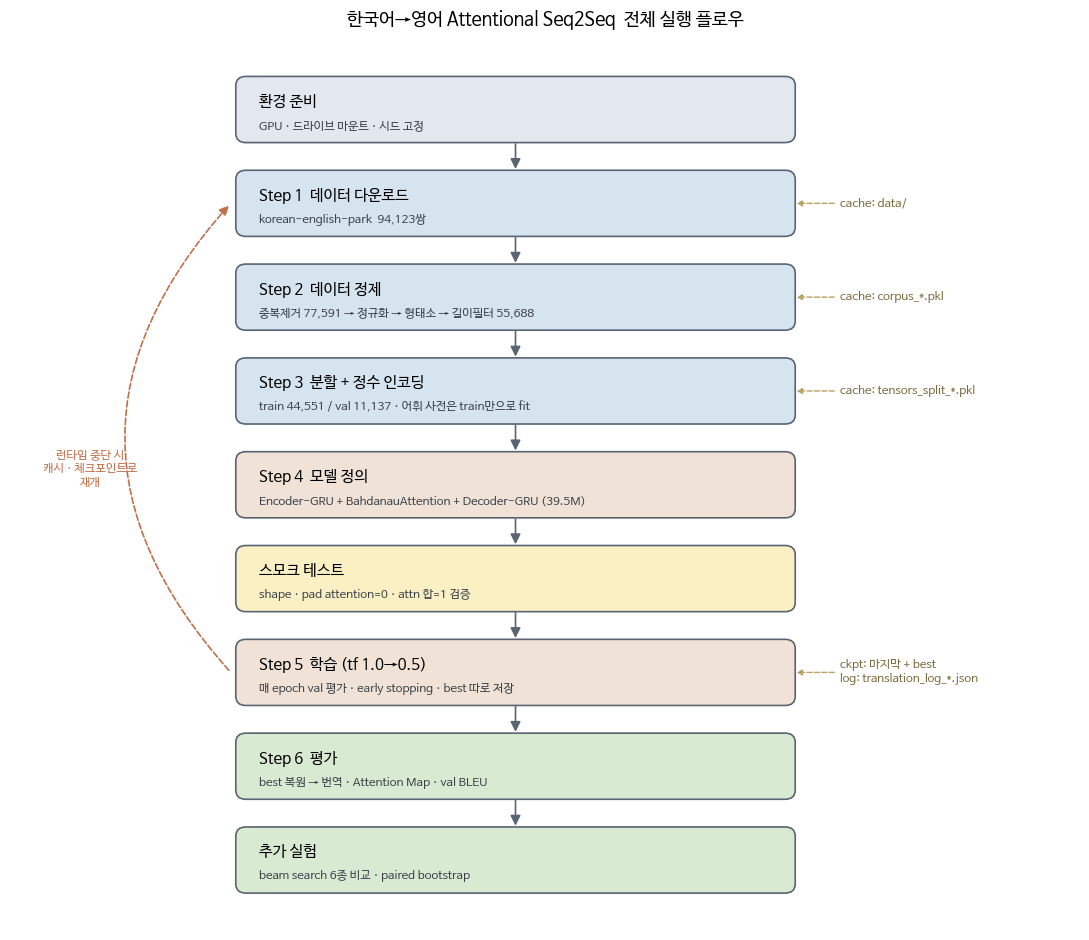

In [33]:
# 전체 실행 플로우 그래프 (PRT 4번 항목)
# 이 셀은 앞 셀들의 상태에 의존하지 않으므로 단독 실행이 가능합니다.
import os

import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

_FONT = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
if os.path.exists(_FONT):
    fm.fontManager.addfont(_FONT)
    plt.rcParams["font.family"] = fm.FontProperties(fname=_FONT).get_name()
plt.rcParams["axes.unicode_minus"] = False

# (제목, 세부 설명, 배경색)
STAGES = [
    ("환경 준비", "GPU · 드라이브 마운트 · 시드 고정", "#E3E8EF"),
    ("Step 1  데이터 다운로드", "korean-english-park  94,123쌍", "#D6E4F0"),
    ("Step 2  데이터 정제",
     "중복제거 77,591 → 정규화 → 형태소 → 길이필터 55,688", "#D6E4F0"),
    ("Step 3  분할 + 정수 인코딩",
     "train 44,551 / val 11,137 · 어휘 사전은 train만으로 fit", "#D6E4F0"),
    ("Step 4  모델 정의",
     "Encoder-GRU + BahdanauAttention + Decoder-GRU (39.5M)", "#F0E2D6"),
    ("스모크 테스트", "shape · pad attention=0 · attn 합=1 검증", "#FBF0C4"),
    ("Step 5  학습 (tf 1.0→0.5)",
     "매 epoch val 평가 · early stopping · best 따로 저장", "#F0E2D6"),
    ("Step 6  평가", "best 복원 → 번역 · Attention Map · val BLEU", "#D9EAD3"),
    ("추가 실험", "beam search 6종 비교 · paired bootstrap", "#D9EAD3"),
]

SIDE = {  # 오른쪽에 붙일 산출물 라벨
    1: "cache: data/",
    2: "cache: corpus_*.pkl",
    3: "cache: tensors_split_*.pkl",
    6: "ckpt: 마지막 + best\nlog: translation_log_*.json",
}

fig, ax = plt.subplots(figsize=(11, 9.5))
box_w, box_h, gap = 6.6, 0.82, 0.40
x0 = 0.6

for i, (title, detail, color) in enumerate(STAGES):
    y = (len(STAGES) - 1 - i) * (box_h + gap)
    ax.add_patch(FancyBboxPatch((x0, y), box_w, box_h,
                                boxstyle="round,pad=0.02,rounding_size=0.12",
                                facecolor=color, edgecolor="#5A6472",
                                linewidth=1.2))
    ax.text(x0 + 0.25, y + box_h * 0.62, title,
            fontsize=11, weight="bold", va="center")
    ax.text(x0 + 0.25, y + box_h * 0.24, detail,
            fontsize=8.5, color="#3A4048", va="center")

    if i < len(STAGES) - 1:
        ax.add_patch(FancyArrowPatch((x0 + box_w / 2, y),
                                     (x0 + box_w / 2, y - gap),
                                     arrowstyle="-|>", mutation_scale=15,
                                     color="#5A6472", linewidth=1.2))

    if i in SIDE:
        ax.annotate(SIDE[i], xy=(x0 + box_w, y + box_h / 2),
                    xytext=(x0 + box_w + 0.55, y + box_h / 2),
                    fontsize=8.5, color="#7A6A3A", va="center",
                    arrowprops=dict(arrowstyle="-|>", color="#B8A362",
                                    linewidth=1.0, linestyle="--"))

# 재시작 루프: 학습 단계에서 캐시 단계로 되돌아오는 화살표
y_train = (len(STAGES) - 1 - 6) * (box_h + gap)
y_cache = (len(STAGES) - 1 - 1) * (box_h + gap)
ax.add_patch(FancyArrowPatch((x0 - 0.08, y_train + box_h / 2),
                             (x0 - 0.08, y_cache + box_h / 2),
                             connectionstyle="arc3,rad=-0.45",
                             arrowstyle="-|>", mutation_scale=14,
                             color="#C0714B", linewidth=1.2, linestyle="--"))
ax.text(x0 - 1.75, (y_train + y_cache) / 2,
        "런타임 중단 시\n캐시 · 체크포인트로\n재개",
        fontsize=8.5, color="#C0714B", ha="center", va="center")

ax.set_xlim(-2.1, x0 + box_w + 3.4)
ax.set_ylim(-0.5, len(STAGES) * (box_h + gap))
ax.axis("off")
ax.set_title("한국어→영어 Attentional Seq2Seq  전체 실행 플로우",
             fontsize=13, pad=16)
plt.tight_layout()
plt.show()


## 5. 회고

### 배운 점

**Attention은 "정렬을 학습하는 장치"라는 걸 그림으로 처음 이해했습니다.**
수식으로는 `score = v^T tanh(W1 h_j + W2 s_{t-1})`이 뭘 하는지 감이 안 왔는데,
Attention Map에서 `사망자`, `일곱` 형태소 열에 밝은 띠가 생기고 그때 디코더가
`deaths`, `killed`를 내놓는 것을 보고 나서야 context vector가 무슨 의미인지 와닿았습니다.

**"에러가 안 나는 버그"가 제일 무섭다는 걸 체감했습니다.**
이 프로젝트에서 위험했던 지점들 — 병렬 쌍 순서 붕괴, `(B,L)`/`(L,B)` 전치 누락,
softmax 축 오지정, `<pad>` attention 누수, 어휘 사전 누수 — 은 **전부 예외를 던지지 않습니다.**
loss도 정상적으로 떨어집니다. 그래서 학습 전에 스모크 테스트로
`<pad> attention = 0`, `attn 합 = 1`을 숫자로 확인하는 습관을 들였고,
빔 서치를 추가할 때도 `beam_size=1 == 순수 greedy`를 `assert`로 먼저 확인했습니다.
이게 이번 프로젝트에서 가장 값진 습관이 되었습니다.

**틀린 진단을 스스로 뒤집은 경험.**
첫 실행에서는 train loss만 보고 "아직 덜 수렴했으니 epoch을 더 늘리면 개선될 것"이라고
적었습니다. validation split을 만들고 다시 학습해 보니 **epoch 11에서 이미 과적합이
시작**되고 있었습니다. 더 돌렸다면 나빠졌을 상황이었습니다.
측정 장치가 없으면 진단이 아니라 추측이라는 걸, 내가 쓴 틀린 문장으로 배웠습니다.

**점수 하나로 결론 내리지 않기.**
beam 5의 BLEU는 기준보다 0.14 높았습니다. 그대로 "빔 서치로 개선했다"고 쓸 뻔했는데,
paired bootstrap 승률이 0.810이라 유의한 차이가 아니었습니다.
반대로 n-gram 차단 조합은 승률 1.000으로 명확했습니다.
**"차이가 있다"와 "차이를 확인하지 못했다"를 구분해서 쓰는 법**을 배운 것이
이번 추가 실험의 가장 큰 소득입니다.

### 아쉬운 점

**1. validation을 모델 선택과 성능 보고에 모두 썼습니다.**
early stopping으로 best epoch을 고른 것도 val이고, BLEU를 보고한 것도 같은 val입니다.
엄밀하게는 val에 대해 낙관적으로 편향된 숫자입니다. 8:1:1로 나눠
**test set을 따로 뒀어야** 했습니다. 이번 프로젝트에서 가장 크게 반성하는 부분입니다.

**2. 절대 성능이 낮습니다.** BLEU 5.86은 실용 수준과는 거리가 멉니다.
반복이 남아 있고, 숫자("일곱" → "16")나 고유명사를 자주 틀립니다.
디코딩을 다듬는 것으로는 한계가 분명했고, 원인은 모델 용량 대비 데이터 부족과
단어 단위 어휘 쪽에 있다고 진단했지만 **그 진단을 실험으로 확인하지는 못했습니다.**

**3. 테스트 문장의 도메인이 학습 데이터와 다릅니다.** 뉴스 말뭉치로 학습해 놓고
"커피는 필요 없다" 같은 일상 단문을 테스트했습니다. 모델이 뉴스 상투구를 끌어오는 게
당연했습니다. 번역기가 못 만든 것도 있지만 **평가 세팅 자체가 모델에 불리했습니다.**

**4. 하이퍼파라미터를 충분히 비교하지 못했습니다.** teacher forcing 스케줄은 시도했지만
hidden_dim, 어휘 크기, 학습률은 한 세트만 돌렸습니다.
특히 "모델이 데이터에 비해 크다"는 진단을 세워 놓고도 작은 모델과 나란히 비교하지
못한 것이 아쉽습니다.

**5. 재개 로직의 빈틈을 세 번에 걸쳐 발견했습니다.** 옵티마이저 상태 → early stopping
카운터 → 루프 진입 전 검사 순으로, 매번 실행해 보고 나서야 찾았습니다.
상태를 저장하는 코드는 "무엇을 저장할까"보다 **"무엇을 빠뜨리면 조용히 잘못되나"**를
먼저 물었어야 했습니다.

### 느낀 점

가장 인상적이었던 건 **epoch별 번역 로그를 시간순으로 읽는 경험**이었습니다.
`시민들은 도시 속에 산다`가 epoch 1의 `the <unk> of the world s <unk> ...`에서
epoch 9의 `the people lived in the cities , the city of living in cities ...`로
변해가는 과정은, 모델이 문장 구조를 조금씩 잡아가는 걸 눈으로 보는 것 같았습니다.
**최종 지표 하나만 남기는 것보다 학습 과정을 로그로 남기는 게 훨씬 많은 정보를 준다**는
걸 배웠습니다.

또 하나는, 이 프로젝트에서 실제로 성능을 끌어올린 변경보다
**무엇이 개선인지 판정할 수 있게 만든 변경**이 더 값졌다는 것입니다.
validation split, bootstrap 신뢰구간, 스모크 테스트는 그 자체로 BLEU를 올리지 않습니다.
하지만 이것들이 없었다면 틀린 진단("더 돌리면 된다")과 틀린 결론("빔 서치가 개선했다")을
그대로 보고서에 썼을 것입니다. **측정을 먼저 만드는 것이 결국 가장 빠른 길**이라는 걸
이번에 체감했습니다.

마지막으로, 런타임이 끊겼을 때 처음부터 다시 돌리는 대신 캐시와 체크포인트를 설계하는 데
시간을 쓴 판단이 옳았습니다. 실제로 여러 번 세션이 끊겼지만 중단된 epoch부터 이어갈 수
있었습니다. **환경의 제약을 코드 설계로 흡수하는 것도 실력이라는 걸** 알게 되었습니다.


## 6. 코드 스타일 · 구조 정리

### PEP8 준수

- 4칸 들여쓰기, 한 줄 88자 이내
- 함수·변수 `snake_case`, 클래스 `PascalCase`, 상수 `UPPER_SNAKE_CASE`
  (`MAX_TOKEN_LEN`, `NUM_WORDS_KO`, `PAD_ID`, `CKPT_PATH`, `VAL_RATIO`)
- import 순서: 표준 라이브러리 → 서드파티 → 로컬, 그룹 사이 한 줄 공백
- 최상위 함수·클래스 정의 사이 두 줄 공백
- 모든 public 함수/클래스에 docstring (필요한 경우 Args/Returns 포함)

### 함수화 · 모듈화 — 중복 제거 사례

| 함수 | 중복이었을 코드 | 어떻게 일반화했나 |
| --- | --- | --- |
| `cached(filename, build_fn, force)` | 다운로드 · 형태소 분석 · 토큰화 각각에 "파일 있으면 로드, 없으면 계산 후 저장" 로직 3벌 | 저장/로드를 고차 함수로 추상화. 새 캐시 대상이 생기면 `build_fn`만 넘기면 됨 |
| `preprocess_sentence(sentence, language)` | 한국어용·영어용 정제 함수 2벌 | 정규식만 언어별로 분기하고 나머지 흐름은 공유 |
| `deduplicate_pairs(src, trg, key)` | source 기준 / target 기준 / 둘 다 기준 코드 3벌 | 중복 판정 기준을 `key` 인자로 파라미터화 |
| `get_korean_tokenizer()` | 분석기 4종에 대한 try/except 블록이 호출 지점마다 반복 | 한 곳에서 폴백을 처리하고 `(이름, morphs 함수)`만 반환 |
| `translate(sentence, model, no_repeat)` | 억제 적용 / 순수 greedy 디코딩 함수 2벌 | `no_repeat` 플래그로 통합 → A/B 비교가 인자 하나로 가능 |
| `generate_hypotheses(model, decode_fn, ...)` | BLEU 계산 셀과 디코딩 비교 셀에 "표본 뽑고 문장 생성" 로직 2벌 | 디코더를 함수로 받아 6종 비교를 같은 코드로 처리. `val_bleu`도 이 함수를 호출 |
| `ensure_sacrebleu()` | sacrebleu import/설치/경고 억제 블록 2벌 | 한 함수로 통합 |
| `beam_decode(..., no_repeat_ngram_sizes, return_attention)` | 순수 빔 / 차단 적용 빔 / BLEU용 경량 빔 3벌 | 인자로 통합. `return_attention=False`로 대량 생성 시 메모리 절약 |
| `save_checkpoint` / `load_checkpoint` / `load_best` | 학습 셀 안에 인라인으로 흩어질 저장 로직 | 함수로 분리하고 config 검증까지 내부에 포함 |

### 설계 원칙

- **부수효과 분리**: `build_corpus`, `build_split_tensors` 같은 순수 계산 함수와,
  저장/로드를 담당하는 `cached`를 분리했습니다. 캐싱 정책이 바뀌어도 전처리 코드는 그대로입니다.
- **실패를 조용히 넘기지 않기**: `load_checkpoint`는 모델 config(차원 + 분할 설정)가
  다르면 예외를 던집니다. 잘못된 가중치를 조용히 로드해 원인 불명의 성능 저하를 만드는 것보다,
  즉시 실패하는 쪽이 디버깅에 유리합니다.
- **캐시 키에 의존성 명시**: 캐시 파일 이름에 분석기 이름 · 어휘 크기 · 분할 비율 · 시드를 넣어
  (`corpus_kiwipiepy_40.pkl`, `tensors_split_kiwipiepy_20000_20000_v20s42.pkl`)
  설정이 바뀌면 캐시가 자동으로 무효화됩니다.
- **검증을 코드로 남기기**: 스모크 테스트 셀과 `assert`는 주석이 아니라 실행되는 문서입니다.
  다음에 이 노트북을 고칠 사람이 같은 실수를 하면 그 자리에서 멈춥니다.
